# STAT201 · 10-hafta · Kompyuter laboratoriyasi (Python)

**Gipotezalarni tekshirish I: nol taqsimotini qurish, $p$-qiymat,
quvvat va $p$-hacking**

Toshkent Xalqaro Universiteti · Iqtisodiyot fakulteti · 2025/2026

---

> **Bu daftar `W10-lab-R.Rmd` ning aynan ekvivalenti.** Matn bir xil,
> kod ikki tilda. Ikkala daftar bir xil MINSTD urugʻlaridan
> foydalanadi va **belgi-ma-belgi bir xil matn** chiqaradi — buni
> `gen/11_lab_check_daftarlar_w10.py` avtomatik tekshiradi.
>
> **Ishga tushirish:** *Kernel → Restart & Run All*. Daftar
> `data/` papkasi bilan bir joyda turishi kerak. Umumiy ishlash
> vaqti ≈ 1 daqiqa.

$$
\newcommand{\Prob}{\mathbb{P}}
\newcommand{\E}{\mathbb{E}}
\newcommand{\Var}{\operatorname{Var}}
\newcommand{\SD}{\operatorname{SD}}
\newcommand{\SE}{\operatorname{SE}}
\newcommand{\Xbar}{\bar{X}}
\newcommand{\phat}{\hat{p}}
\newcommand{\xbar}{\bar{x}}
\newcommand{\Norm}{\mathcal{N}}
\newcommand{\Bin}{\operatorname{Bin}}
$$

# Laboratoriya haqida

**Maqsad.** Bugun siz **nol taqsimotini oʻz qoʻlingiz bilan quradingiz**
— soʻng uni **qanchalik oson suiisteʼmol qilish mumkinligini
oʻlchaysiz**. Maʼruzada $p$-qiymatning taʼrifi aytildi: *agar $H_0$
toʻgʻri boʻlsa, kuzatilganidek yoki undan keskinroq natija olish
ehtimolligi*. Bu taʼrif — **sanaladigan** daʼvo. Bugun biz uni
sanaymiz: hech qanday formulaga tayanmasdan, $H_0$ toʻgʻri boʻlgan
dunyoni 20 000 marta yaratib, natijalarni **sanab**.

9-haftada savol «$\mu$ qancha?» edi va javob **son** boʻlgan. Bu hafta
savol «$\mu$ falon songa tengmi?» va javob **qaror**. Har bir qaror
xato boʻlishi mumkin — shuning uchun bugun xatolarning ikkala turini
ham **oʻlchaymiz**.

Ushbu mashgʻulot yettita narsani **isbotlaydi yoki buzadi**:

1. **Test — ishonch oraligʻining boshqa tomoni.** Oraliqning
   *chegarasida* $p$ aynan $0{,}050000$ ga teng chiqadi. Taxminan
   emas — **aynan**.
2. **$p$-qiymatni formulasiz hisoblash mumkin.** Nol taqsimotini
   quramiz va **sanaymiz**; keyin aniq binomial, $z$-test va
   uzluksizlik tuzatmasi bilan solishtiramiz.
3. **$H_0$ ostida $p$ tekis taqsimlangan.** Bu bitta oʻlchangan fakt
   butun haftani tushuntiradi.
4. **I va II tur xatolari almashtiriladi.** Quvvatni nazariy
   hisoblaymiz va bitta nuqtasini **simulyatsiya bilan tekshiramiz**.
5. **$p$-hacking oʻlchanadi, aytilmaydi.** Uchta suiisteʼmol shakli sof
   shovqin ustida ishga tushiriladi: $0{,}05$ oʻrniga $0{,}6411$,
   $0{,}3476$ va $0{,}2624$ chiqadi.
6. **Statistik ahamiyat amaliy ahamiyat emas.** Bir xil, arzimas
   effekt $n$ oshgani sayin «ahamiyatli» boʻlib qoladi.
7. **Natijani yozish — alohida koʻnikma.** $p$ hech qachon yolgʻiz
   berilmaydi: **effekt hajmi $+$ ishonch oraligʻi $+$ $p$**.

> **Haftaning markaziy gʻoyasi.** 9-hafta yakunida shunday deyilgan
> edi: «ishonch oraligʻi ikkinchi savolga ham javob beradi». Bugun
> buni **isbotlaymiz**, keyin esa shu asbobning qanchalik oson
> sinishini **oʻlchaymiz**.

**Ish zanjiri.** Har bir topshiriqda quyidagi ketma-ketlikni yozma
ravishda bajarasiz:

> **statistik tushuncha → maʼlumot → kod → natija → talqin → qaror**

Faqat kod yozib, natijani izohsiz qoldirish — topshiriq bajarilmagan
hisoblanadi. Baholashning $60\,\%$ i aynan *talqin* va *qaror*
bosqichlariga beriladi.

**Vaqt va ball taqsimoti (120 daqiqa, 120 ball + 5 bonus).**

| # | Mazmun | Daqiqa | Blum | Qiyinlik | Ball |
|---|---|---|---|---|---|
| 0 | Muhitni sozlash, MINSTD va maʼlumot | 5 | — | — | — |
| 1 | Koʻprik: oraliq $\leftrightarrow$ test | 12 | Qoʻllash | 3 (Amaliy) | 14 |
| 2 | Nol taqsimotini qurish va sanash | 16 | Tahlil | 4 (Analitik) | 18 |
| 3 | $H_0$ ostida $p$ tekis taqsimlangan | 14 | Tahlil | 4 (Analitik) | 16 |
| 4 | I va II tur xatolari, quvvat | 16 | Tahlil | 4 (Analitik) | 16 |
| 5 | $p$-hacking laboratoriyasi | 28 | Baholash | 5 (Ilgʻor) | 26 |
| 6 | Statistik va amaliy ahamiyat | 15 | Baholash | 5 (Ilgʻor) | 16 |
| 7 | Natijani yozish: hisobot tili | 14 | Yaratish | 5 (Ilgʻor) | 14 |
| 8 | AI yordamida: $p$-qiymat talqinidagi xato | uyda | Yaratish | 6 (Tadqiqot) | +5 |

**Oldingi bilim.** Sizga quyidagilar allaqachon maʼlum boʻlishi kerak:
MINSTD generatori va urugʻ (2-hafta); shartli ehtimollik va prokuror
xatosi (3-hafta); normal taqsimot va $z$-baho (5-hafta); binomial
taqsimot va **uzluksizlik tuzatmasi** (7-hafta); tanlanma taqsimoti,
$\SE$ va muvaffaqiyat–muvaffaqiyatsizlik sharti (7-hafta);
$t$-taqsimot, erkinlik darajasi va ishonch oraligʻi (9-hafta).

**Bu hafta nimani qilmaymiz.** Ikki tanlanmani solishtirish, juftlashgan
testlar, $\chi^{2}$, ANOVA, noparametrik usullar va regressiya —
**11-haftadan** boshlanadi. Bugun **faqat bitta tanlanma**: bitta
oʻrtacha yoki bitta ulush. Bonferroni tuzatmasi bugun faqat *eslatib*
oʻtiladi; toʻliq muolajasi 11-haftada.

---

# 0-bosqich. Muhitni sozlash

In [1]:
# --- Muhit va versiyalar ----------------------------------------------
# Python UTF-8 ni standart sifatida ishlatadi, shuning uchun R dagi
# LC_CTYPE tuzogʻi bu yerda YOʻQ. Ammo QOIDA saqlanadi: toifa nomlarini
# kod ichida literal yozmang — ularni unique() orqali FAYLDAN oling va
# POZITSIYA boʻyicha tanlang. Shunda ikkala daftar bir xil ishlaydi.
import sys
print("MUHIT: python", sys.version.split()[0],
      "| kodlash", sys.getdefaultencoding())

MUHIT: python 3.11.15 | kodlash utf-8


In [2]:
# --- Kerakli kutubxonalar ---------------------------------------------
import math
import numpy as np                  # sonli massivlar
import pandas as pd                 # jadval koʻrinishidagi maʼlumot
import matplotlib
import matplotlib.pyplot as plt     # grafiklar
from scipy import stats             # qt / pt / pbinom ekvivalentlari

# Okabe–Ito palitrasi: rang koʻrmaslikka moslashgan.
oiBlue = "#0072B2"; oiOrange = "#E69F00"; oiGreen = "#009E73"
oiPink = "#CC79A7"; oiVerm   = "#D55E00"; oiSky   = "#56B4E9"
oiYell = "#F0E442"; oiGrey   = "#5A6470"

plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (7, 4.2), "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold"})

# QOIDA (2-haftadan): grafik yorliqlarida faqat ASCII harflar —
# shunda daftar har qanday shrift sozlamasida bir xil koʻrinadi.
print("MUHIT: matplotlib", matplotlib.__version__)

MUHIT: matplotlib 3.10.9


In [3]:
# --- IKKI DAFTAR BIR XIL MATN CHIQARISHI UCHUN YORDAMCHILAR ------------
# (1) ha(): R «TRUE», Python esa «True» yozadi. Mantiqiy qiymatni
#     OʻZIMIZ formatlaymiz.
def ha(b):
    return "HA" if bool(b) else "YOʻQ"

# (2) pad()/padl(): R ning sprintf("%-16s") formati satrni BAYT boʻyicha
#     toʻldiradi, Python esa BELGI boʻyicha. «YOʻQ» da 4 ta belgi, ammo
#     5 ta bayt bor — shu sababli oʻzbekcha yorliqlarni formatga bermay,
#     kenglikni OʻZIMIZ hisoblaymiz.
def pad(s, n):                      # chapga tekislash (oʻngdan boʻshliq)
    return s + " " * max(0, n - len(s))

def padl(s, n):                     # oʻngga tekislash (chapdan boʻshliq)
    return " " * max(0, n - len(s)) + s

# (3) P_(): R dagi sprintf + cat ekvivalenti. Har bir son QOʻLDA
#     formatlanadi, tilning avtomatik chiqarish mexanizmiga tayanmaymiz.
def P_(fmt, *a):
    print(fmt % a)

# (4) Dispersiya: MAXRAJNI HAR DOIM OSHKORA YOZAMIZ.
#     R da var() -> n-1, Python da np.var() -> N. Chalkashlik shu yerdan
#     chiqadi, shuning uchun ikkala daftarda ham oʻz funksiyamiz bor.
def varS(x):                        # maxraj n-1
    x = np.asarray(x, dtype=float)
    return float(((x - x.mean()) ** 2).sum() / (len(x) - 1))

def varP(x):                        # maxraj n
    x = np.asarray(x, dtype=float)
    return float(((x - x.mean()) ** 2).sum() / len(x))

def sdS(x):
    return math.sqrt(varS(x))

def sdP(x):
    return math.sqrt(varP(x))

# (5) Qator boʻyicha koʻrsatkichlar: matritsaning HAR BIR QATORI —
#     bitta tanlanma.
def qatorOrtacha(M):
    return M.mean(axis=1)

def qatorVarS(M):                   # maxraj n-1 (STATISTIKA)
    mu = M.mean(axis=1, keepdims=True)
    return ((M - mu) ** 2).sum(axis=1) / (M.shape[1] - 1)

# (6) p-qiymat funksiyalari — bu haftaning asosiy asboblari.
def p_t2(t, df):                    # ikki tomonlama t
    return 2 * (1 - stats.t.cdf(np.abs(t), df))

def p_z2(z):                        # ikki tomonlama z
    return 2 * stats.norm.cdf(-np.abs(z))

# (7) Kolmogorov masofasi: empirik taqsimot bilan TEKIS taqsimot
#     orasidagi eng katta farq. Formulani oshkora yozamiz — shunda
#     ikkala tilda AYNAN bir xil son chiqadi.
def kolm(p):
    N = len(p); ps = np.sort(np.asarray(p, dtype=float))
    i = np.arange(1, N + 1)
    return float(max((i / N - ps).max(), (ps - (i - 1) / N).max()))

# (8) Kritik qiymatlar. z ni LITERAL yozamiz (ikki tilda bir xil bit).
Z975 = 1.959964      # z_{0,975}
Z80  = 0.841621      # z_{0,80}  — quvvat hisobida kerak

def tkr(daraja, df):
    return float(stats.t.ppf(daraja, df))

In [4]:
# --- MINSTD generatori (2-haftadan beri oʻzgarmagan) -------------------
# Nima uchun oʻzimizning generatorimiz kerak?
#   R:      set.seed(2026); runif(3)
#   Python: np.random.default_rng(2026).random(3)
# Bu ikkisi BOSHQA-BOSHQA sonlar beradi. Ikkalasi ham toʻgʻri, lekin
# ikkalasi ham bir-biriga mos emas. Shu sababli kursda tasodifiylik
# kerak boʻlganda HAR DOIM quyidagi 4 qatorli generator ishlatiladi:
#     x <- (48271 * x) mod 2147483647,    u <- x / 2147483647
# Bu — Lehmer (1951) generatori, «MINSTD» nomi bilan mashhur.
A_ = 48271; M_ = 2147483647

def minstd(urug):
    holat = {"x": urug % M_}
    def gen(n):                      # n ta u ~ U(0,1) qaytaradi
        n = int(n); o = np.empty(n); x = holat["x"]
        for i in range(n):
            x = (A_ * x) % M_; o[i] = x
        holat["x"] = x
        return o / M_
    return gen

# Indeks tanlash: 0 dan hi-1 gacha butun son (R bilan bir xil).
# Python da massiv 0 dan boshlanadi — «+1» KERAK EMAS.
def indeks(gen, n, hi):
    return (gen(n) * hi).astype(np.int64)

# Box–Muller: tekis sonlardan normal sonlar.
# DIQQAT — CHIQISH TARTIBI ATAYLAB QAYD ETILGAN: avval BARCHA
# kosinuslar, keyin BARCHA sinuslar. Tartib qayd etilmasa, R va Python
# bir xil urugʻdan bir xil sonlarni BOSHQA KETMA-KETLIKDA beradi va
# ikki daftar ajralib ketadi.
def minstd_norm(gen, n):
    n = int(n); m2 = n + (n % 2)                # juft songa toʻldiramiz
    us = gen(m2).reshape(-1, 2)
    r = np.sqrt(-2 * np.log(us[:, 0])); th = 2 * np.pi * us[:, 1]
    return np.concatenate([r * np.cos(th), r * np.sin(th)])[:n]

# Nazorat qiymati: urugʻ 2026 dan keyingi uchta son.
g = minstd(2026); u3 = g(3)
P_("=== 0-BOSQICH: MINSTD NAZORATI ===")
P_("urugʻ 2026 -> u1 = %.10f  u2 = %.10f  u3 = %.10f", u3[0], u3[1], u3[2])
P_("bu uchta son ikkinchi tildagi daftarda ham AYNAN shunday chiqishi shart")
g = minstd(7); z4 = minstd_norm(g, 4)
P_("Box-Muller nazorati (urugʻ 7): %+.8f %+.8f %+.8f %+.8f",
   z4[0], z4[1], z4[2], z4[3])
P_("birinchi ikkitasi KOSINUSLAR, keyingi ikkitasi SINUSLAR")

# Solishtirish uchun: tilning OʻZ generatori (bu satr ikki tilda FARQ QILADI)
print("MUHIT: Python ning default_rng(2026).random(1) = %.10f  (R da boshqa son)"
      % np.random.default_rng(2026).random(1)[0])

=== 0-BOSQICH: MINSTD NAZORATI ===
urugʻ 2026 -> u1 = 0.0455402984  u2 = 0.2757419647  u3 = 0.3403783731
bu uchta son ikkinchi tildagi daftarda ham AYNAN shunday chiqishi shart
Box-Muller nazorati (urugʻ 7): -3.45796234 +0.09683932 -2.35725028 +1.76549950
birinchi ikkitasi KOSINUSLAR, keyingi ikkitasi SINUSLAR
MUHIT: Python ning default_rng(2026).random(1) = 0.1789348137  (R da boshqa son)


In [5]:
# --- Ikkita haqiqiy maʼlumot toʻplami ---------------------------------
# A. markaziy-osiyo-hosildorlik.csv — 5 mamlakat x 27 yil (1992–2018),
#    hosildorlik t/ga. Manba: FAOSTAT / Our World in Data (OWID).
# B. kinolar-byudjet.csv — 2 467 film (2000–2018), byudjet AQSh
#    dollarida. Manba: The Numbers / Kaggle «movie industry».
#    BUGUN HAM BU FAYL — BUTUN BOSH TOʻPLAM (9-haftadagi kabi).
DATA  = "data"
hosil = pd.read_csv(DATA + "/markaziy-osiyo-hosildorlik.csv", encoding="utf-8")
kino  = pd.read_csv(DATA + "/kinolar-byudjet.csv", encoding="utf-8")

# QOIDA: mamlakat nomini kod ichida LITERAL yozmaymiz — fayldan olamiz
# va POZITSIYA boʻyicha tanlaymiz (R dagi lokal tuzogʻi).
mamlar = list(pd.unique(hosil["mamlakat"]))
UZ     = mamlar[0]                        # faylda birinchi kelgan mamlakat
uz     = hosil[(hosil["mamlakat"] == UZ) & (hosil["yil"] >= 2009)
               & (hosil["yil"] <= 2018)]
xw     = uz["bugdoy"].to_numpy(dtype=float)   # 9-haftadagi AYNI tanlanma

b    = kino["byudjet"].to_numpy(dtype=float) / 1e6   # mln dollarda
Nb   = len(b)
MU   = float(b.mean())                    # PARAMETR
SIG  = sdP(b)                             # PARAMETR (maxraj N)
SIG2 = SIG ** 2

P_("")
P_("=== 0-BOSQICH: MAʼLUMOT ===")
P_("A. hosildorlik fayli: %d qator, %d ta mamlakat, %d-%d yillar",
   len(hosil), len(mamlar), hosil["yil"].min(), hosil["yil"].max())
P_("   tanlangan mamlakat (pozitsiya 1) = %s", UZ)
P_("   bugʻdoy 2009-2018, n = %d, birlik t/ga", len(xw))
P_("   qiymatlar: %s", ", ".join("%.3f" % v for v in xw))
P_("B. kinolar fayli (BOSH TOʻPLAM): N = %d, birlik mln $", Nb)
P_("   mu    = %.6f   <- PARAMETR, qatʼiy son", MU)
P_("   sigma = %.6f   <- PARAMETR (maxraj N)", SIG)
P_("")
P_("MANBA: OWID/FAOSTAT (hosildorlik) · The Numbers/Kaggle (kinolar).")
P_("Ikkalasi ham HAQIQIY maʼlumot. Simulyatsiya natijalari yonida esa")
P_("har doim generator nomi (MINSTD) va urugʻ koʻrsatiladi.")


=== 0-BOSQICH: MAʼLUMOT ===
A. hosildorlik fayli: 135 qator, 5 ta mamlakat, 1992-2018 yillar
   tanlangan mamlakat (pozitsiya 1) = Oʻzbekiston
   bugʻdoy 2009-2018, n = 10, birlik t/ga
   qiymatlar: 4.901, 4.600, 4.556, 4.710, 4.739, 4.782, 4.818, 4.802, 4.316, 4.126
B. kinolar fayli (BOSH TOʻPLAM): N = 2467, birlik mln $
   mu    = 35.804977   <- PARAMETR, qatʼiy son
   sigma = 37.404842   <- PARAMETR (maxraj N)

MANBA: OWID/FAOSTAT (hosildorlik) · The Numbers/Kaggle (kinolar).
Ikkalasi ham HAQIQIY maʼlumot. Simulyatsiya natijalari yonida esa
har doim generator nomi (MINSTD) va urugʻ koʻrsatiladi.


---

# 1-topshiriq. Koʻprik: ishonch oraligʻi va test — bir xil narsa {#t1}

> **Blum:** Qoʻllash · **Qiyinlik:** 3 (Amaliy) · **Ball:** 14 ·
> **Vaqt:** 12 daqiqa

**Statistik tushuncha.** 9-haftada siz $\mu$ uchun ishonch oraligʻini
qurdingiz. Bugungi test yangi matematika emas: u **aynan oʻsha
hisobni boshqa tomondan** oʻqiydi.

$$t=\frac{\xbar-\mu_0}{s/\sqrt{n}},\qquad
p = 2\,\Prob\bigl(T_{n-1} > |t|\bigr).$$

**Daʼvo (aynan, taxminan emas):**

$$\mu_0 \in \bigl[\xbar \pm t_{1-\alpha/2}(n-1)\cdot \SE\bigr]
\iff p \ge \alpha .$$

Buni **isbotlamaymiz — tekshiramiz**. Agar daʼvo toʻgʻri boʻlsa,
oraliqning *chegarasida* $p$ aynan $\alpha$ ga teng chiqishi shart.

**Maʼlumot.** Oʻzbekistonda bugʻdoy hosildorligi, 2009–2018, $n=10$,
t/ga (OWID / FAOSTAT — **haqiqiy**).

> **Halollik sharti.** Bu — *vaqt qatori*, tasodifiy tanlanma emas.
> Ketma-ket yillar bir-biriga bogʻliq (ob-havo, texnologiya, siyosat),
> demak bogʻliqsizlik sharti buzilgan. Testni **mashq sifatida**
> oʻtkazamiz va bu buzilishni talqin bosqichida **ochiq aytamiz**.

**Kod.**

In [6]:
# --- 1A: bitta tanlanma, mu_0 lar toʻri boʻyicha test -----------------
n1  = len(xw); xb1 = float(xw.mean()); s1 = sdS(xw); se1 = s1 / math.sqrt(n1)
tc1 = tkr(0.975, n1 - 1)
lo1 = xb1 - tc1 * se1; hi1 = xb1 + tc1 * se1

P_("=== 1-TOPSHIRIQ: ORALIQ VA TEST -- AYNI BIR NARSA ===")
P_("maʼlumot: Oʻzbekiston bugʻdoy hosildorligi 2009-2018 (OWID/FAOSTAT)")
P_("n = %d   xbar = %.6f   s = %.6f   SE = %.6f", n1, xb1, s1, se1)
P_("t_0,975(%d) = %.6f", n1 - 1, tc1)
P_("9-haftadagi 95 foizli ishonch oraligʻi: [%.6f; %.6f]", lo1, hi1)
P_("")
P_("%s%s%s%s%s", padl("mu_0", 12), padl("t", 12), padl("p (2 tomonl.)", 16),
   padl("alpha=0,05 da", 16), padl("oraliq ichidami?", 18))
for mu0 in [4.30, 4.40, lo1, 4.50, xb1, 4.75, hi1, 4.90]:
    tt = (xb1 - mu0) / se1; pv = float(p_t2(tt, n1 - 1))
    if abs(pv - 0.05) < 1e-9:
        qrr = "CHEGARA"; ins = "chegara"
    else:
        qrr = "RAD ETILADI" if pv < 0.05 else "rad etilmaydi"
        ins = ha(lo1 <= mu0 <= hi1)
    P_("%s%s%s%s%s",
       padl("%.6f" % mu0, 12), padl("%+.6f" % tt, 12),
       padl("%.6f" % pv, 16), padl(qrr, 16), padl(ins, 18))
P_("")
P_("DIQQAT: chegaradagi ikki satrda p = 0,050000 -- AYNAN, taxminan emas.")
P_("Demak ishonch oraligʻi = RAD ETILMAYDIGAN barcha mu_0 larning toʻplami.")

=== 1-TOPSHIRIQ: ORALIQ VA TEST -- AYNI BIR NARSA ===
maʼlumot: Oʻzbekiston bugʻdoy hosildorligi 2009-2018 (OWID/FAOSTAT)
n = 10   xbar = 4.635000   s = 0.244607   SE = 0.077351
t_0,975(9) = 2.262157
9-haftadagi 95 foizli ishonch oraligʻi: [4.460019; 4.809981]

        mu_0           t   p (2 tomonl.)   alpha=0,05 da  oraliq ichidami?
    4.300000   +4.330883        0.001903     RAD ETILADI              YOʻQ
    4.400000   +3.038082        0.014061     RAD ETILADI              YOʻQ
    4.460019   +2.262157        0.050000         CHEGARA           chegara
    4.500000   +1.745281        0.114893   rad etilmaydi                HA
    4.635000   +0.000000        1.000000   rad etilmaydi                HA
    4.750000   -1.486721        0.171258   rad etilmaydi                HA
    4.809981   -2.262157        0.050000         CHEGARA           chegara
    4.900000   -3.425922        0.007557     RAD ETILADI              YOʻQ

DIQQAT: chegaradagi ikki satrda p = 0,050000 -- AYNAN, taxmina

In [7]:
# --- 1B: koʻprik har qanday alpha da ishlaydimi? ----------------------
# Nazariya: p = alpha boʻladigan mu_0 aynan (1-alpha) oraligʻining
# chegarasi. Uni ikki yoʻl bilan topamiz va solishtiramiz.
P_("")
P_("--- 1B: koʻprik uchta ishonch darajasida ---")
P_("%s%s%s%s%s", padl("alpha", 9), padl("t_krit", 11),
   padl("oraliq quyi", 14), padl("oraliq yuqori", 15),
   padl("chegarada p", 14))
for al in [0.10, 0.05, 0.01]:
    tk = tkr(1 - al / 2, n1 - 1)
    lo = xb1 - tk * se1; hi = xb1 + tk * se1
    pv = float(p_t2((xb1 - lo) / se1, n1 - 1))
    P_("%s%s%s%s%s", padl("%.2f" % al, 9), padl("%.6f" % tk, 11),
       padl("%.6f" % lo, 14), padl("%.6f" % hi, 15), padl("%.6f" % pv, 14))
P_("")
P_("--- 1C: chegara atrofida p ning ishorasi qanday almashadi ---")
P_("%s%s%s%s", padl("mu_0", 12), padl("t", 12), padl("p", 12),
   padl("qaror", 16))
for d in [-0.004, -0.002, 0, 0.002, 0.004]:
    mu0 = lo1 + d; tt = (xb1 - mu0) / se1; pv = float(p_t2(tt, n1 - 1))
    P_("%s%s%s%s", padl("%.6f" % mu0, 12), padl("%+.6f" % tt, 12),
       padl("%.6f" % pv, 12),
       padl("RAD ETILADI" if pv < 0.05 else "rad etilmaydi", 16))
P_("")
P_("Yaxlitlangan chegara bilan ehtiyot boʻling:")
P_("  mu_0 = 4.460000 (yaxlitlangan) -> p = %.6f -> %s",
   float(p_t2((xb1 - 4.46) / se1, n1 - 1)),
   "RAD ETILADI" if float(p_t2((xb1 - 4.46) / se1, n1 - 1)) < 0.05
   else "rad etilmaydi")
P_("  mu_0 = %.6f (aniq)         -> p = %.6f -> CHEGARA",
   lo1, float(p_t2((xb1 - lo1) / se1, n1 - 1)))
P_("Chegara CHEKSIZ nozik: 0,0001 t/ga farq qarorni almashtiradi.")
P_("Bu -- 'p = 0,049 va p = 0,051 tubdan farq qiladi' xatosining ildizi.")


--- 1B: koʻprik uchta ishonch darajasida ---
    alpha     t_krit   oraliq quyi  oraliq yuqori   chegarada p
     0.10   1.833113      4.493206       4.776794      0.100000
     0.05   2.262157      4.460019       4.809981      0.050000
     0.01   3.249836      4.383621       4.886379      0.010000

--- 1C: chegara atrofida p ning ishorasi qanday almashadi ---
        mu_0           t           p           qaror
    4.456019   +2.313869    0.045945     RAD ETILADI
    4.458019   +2.288013    0.047930     RAD ETILADI
    4.460019   +2.262157    0.050000   rad etilmaydi
    4.462019   +2.236301    0.052157   rad etilmaydi
    4.464019   +2.210445    0.054406   rad etilmaydi

Yaxlitlangan chegara bilan ehtiyot boʻling:
  mu_0 = 4.460000 (yaxlitlangan) -> p = 0.049980 -> RAD ETILADI
  mu_0 = 4.460019 (aniq)         -> p = 0.050000 -> CHEGARA
Chegara CHEKSIZ nozik: 0,0001 t/ga farq qarorni almashtiradi.
Bu -- 'p = 0,049 va p = 0,051 tubdan farq qiladi' xatosining ildizi.


**Talqin.** Yozma javob bering:

1. Chegaradagi $p$ nima uchun **aynan** $0{,}050000$ chiqdi? Buni
   $t$ ning taʼrifidan bir qatorda koʻrsating.
2. 1B jadvalida uchta $\alpha$ uchun ham koʻprik ishladi. Bu qoida
   $t$-taqsimotning **qaysi xossasiga** tayanadi?
3. 1C dagi $0{,}0001$ t/ga farq qarorni oʻzgartirdi. «$p=0{,}049$
   kashfiyot, $p=0{,}051$ muvaffaqiyatsizlik» degan amaliyot haqida
   bundan nima kelib chiqadi?
4. $\mu_0=4{,}635$ da $p=1{,}000000$. Bu «$H_0$ isbotlandi» degani
   emas — nima uchun? Javobingizda **quvvat** soʻzini ishlating
   (4-topshiriqdan keyin qaytib keling).
5. **Halollik.** Bu vaqt qatori edi. Bogʻliqsizlik buzilgani $p$ ga
   qaysi tomonga taʼsir qiladi deb oʻylaysiz?

**Qaror.** Hamkasbingiz «men ishonch oraligʻini hisobladim, endi
alohida test ham oʻtkazishim kerak» deydi. Unga **bir jumlada** javob
bering va javobingizni yuqoridagi jadvalning qaysi satri bilan
asoslaysiz — koʻrsating.

---

# 2-topshiriq. Nol taqsimotini qurish va $p$ ni sanash {#t2}

> **Blum:** Tahlil · **Qiyinlik:** 4 (Analitik) · **Ball:** 18 ·
> **Vaqt:** 16 daqiqa

**Statistik tushuncha.** $p$-qiymat — bu **formula emas, taʼrif**:

$$p=\Prob\bigl(\text{shunday yoki keskinroq maʼlumot}\mid H_0\bigr).$$

Taʼrifda «hisoblash» degan soʻz yoʻq — «ehtimollik» bor. Ehtimollikni
esa **sanash** mumkin: $H_0$ toʻgʻri boʻlgan dunyoni koʻp marta
yaratamiz va kuzatilganidek keskin natijalar necha marta chiqqanini
sanaymiz. Formulalar keyin keladi — va ular shu sanoqqa **yaqinlashish**
uchun mavjud.

**Savol.** Kinolarning $40\,\%$ i PG-13 mi?
$H_0: p=0{,}40$, $H_1: p\ne0{,}40$. 9-haftadagi tanlanma: $n=100$,
kuzatilgan PG-13 soni $=34$, $\phat=0{,}34$.

**Maʼlumot.** Bosh toʻplamda 2 467 film bor, ammo **9 tasida reyting
yoʻq**. Bu 9 ta filmni jimgina «PG-13 emas» deb hisoblash — xato
emas, *tanlov*; ammo u **oshkora aytilishi** shart.

**Kod.**

In [8]:
# --- 2A: yoʻq qiymatlar. MAXRAJNI OSHKORA EʼLON QILAMIZ ---------------
# R da  NA == "PG-13"  ->  NA,  va yigʻindi jimgina NA ga aylanadi.
# Python (pandas) da  NaN == "PG-13"  ->  False, yaʼni «PG-13 emas».
# IKKI TIL IKKI XIL JAVOB BERADI. Yechim: NA ni OSHKORA boshqarish.
yoq  = kino["reyting"].isna().to_numpy()
pg13 = ((~yoq) & (kino["reyting"].to_numpy() == "PG-13")).astype(int)

P_("=== 2-TOPSHIRIQ (A): MAXRAJNI TANLASH ===")
P_("jami film = %d · reytingi yoʻq (NA) = %d · reytingi bor = %d",
   len(yoq), int(yoq.sum()), int((~yoq).sum()))
P_("PG-13 soni = %d", int(pg13.sum()))
P_("p (barcha filmlar,   maxraj %d) = %.6f", len(yoq), pg13.sum() / len(yoq))
P_("p (reytingi borlar,  maxraj %d) = %.6f", int((~yoq).sum()),
   pg13.sum() / (~yoq).sum())
P_("farq = %.6f -- kichik, AMMO uni JIM oʻtkazib yuborish mumkin emas.",
   pg13.sum() / (~yoq).sum() - pg13.sum() / len(yoq))
P_("Bugungi testda bu son ISHLATILMAYDI: H_0 ni maʼlumotdan OLMAYMIZ.")
P_("H_0: p = 0,40 -- bu tashqi daʼvo (masalan prodyuserlar uyushmasi).")

=== 2-TOPSHIRIQ (A): MAXRAJNI TANLASH ===
jami film = 2467 · reytingi yoʻq (NA) = 9 · reytingi bor = 2458
PG-13 soni = 896
p (barcha filmlar,   maxraj 2467) = 0.363194
p (reytingi borlar,  maxraj 2458) = 0.364524
farq = 0.001330 -- kichik, AMMO uni JIM oʻtkazib yuborish mumkin emas.
Bugungi testda bu son ISHLATILMAYDI: H_0 ni maʼlumotdan OLMAYMIZ.
H_0: p = 0,40 -- bu tashqi daʼvo (masalan prodyuserlar uyushmasi).


In [9]:
# --- 2B: NOL TAQSIMOTINI QURAMIZ (hech qanday formula yoʻq) -----------
# 1-qadam: H_0 toʻgʻri deb faraz qilamiz -> har bir kino 0,40
#          ehtimollik bilan PG-13.
# 2-qadam: 100 ta kinoni shu qoida bilan «yaratamiz».
# 3-qadam: buni 20 000 marta takrorlaymiz -> NOL TAQSIMOTI.
# 4-qadam: kuzatilganidek yoki keskinroq natijalarni SANAYMIZ.
p0 = 0.40; nobs = 100; xobs = 34; phat = xobs / nobs
M  = 20000
g  = minstd(20261001)
sim = (g(M * nobs) < p0).astype(int).reshape(M, nobs).sum(axis=1)

dobs = abs(xobs - nobs * p0)             # kuzatilgan chetlashish
keskin = np.abs(sim - nobs * p0) >= dobs  # «shunday yoki keskinroq»

P_("")
P_("=== 2-TOPSHIRIQ (B): NOL TAQSIMOTI -- SIMULYATSIYA ===")
P_("generator MINSTD, urugʻ 20261001, M = %d takror", M)
P_("nol taqsimotining oʻrtachasi = %.4f   (nazariy n*p_0 = %.1f)",
   sim.mean(), nobs * p0)
P_("nol taqsimotining SD si      = %.4f   (nazariy sqrt(n p(1-p)) = %.4f)",
   sdS(sim), math.sqrt(nobs * p0 * (1 - p0)))
P_("kuzatilgan chetlashish |%d - %.0f| = %.0f", xobs, nobs * p0, dobs)
P_("«shunday yoki keskinroq» degani: X <= %.0f  YOKI  X >= %.0f",
   nobs * p0 - dobs, nobs * p0 + dobs)
P_("shunday natijalar soni = %d (jami %d dan)", int(keskin.sum()), M)
P_("p-QIYMAT (simulyatsiya) = %d/%d = %.6f", int(keskin.sum()), M,
   keskin.mean())
P_("")
P_("Nol taqsimotining dumi (har bir qiymat necha marta chiqdi):")
P_("%s%s%s%s", padl("X", 6), padl("chastota", 11), padl("ulush", 11),
   padl("keskinmi?", 12))
for v in [30, 32, 34, 36, 40, 44, 46, 48]:
    P_("%s%s%s%s", padl("%d" % v, 6),
       padl("%d" % int((sim == v).sum()), 11),
       padl("%.5f" % (sim == v).mean(), 11),
       padl(ha(abs(v - nobs * p0) >= dobs), 12))


=== 2-TOPSHIRIQ (B): NOL TAQSIMOTI -- SIMULYATSIYA ===
generator MINSTD, urugʻ 20261001, M = 20000 takror
nol taqsimotining oʻrtachasi = 39.9931   (nazariy n*p_0 = 40.0)
nol taqsimotining SD si      = 4.8956   (nazariy sqrt(n p(1-p)) = 4.8990)
kuzatilgan chetlashish |34 - 40| = 6
«shunday yoki keskinroq» degani: X <= 34  YOKI  X >= 46
shunday natijalar soni = 5232 (jami 20000 dan)
p-QIYMAT (simulyatsiya) = 5232/20000 = 0.261600

Nol taqsimotining dumi (har bir qiymat necha marta chiqdi):
     X   chastota      ulush   keskinmi?
    30        192    0.00960          HA
    32        434    0.02170          HA
    34        776    0.03880          HA
    36       1164    0.05820        YOʻQ
    40       1636    0.08180        YOʻQ
    44       1188    0.05940        YOʻQ
    46        824    0.04120          HA
    48        413    0.02065          HA


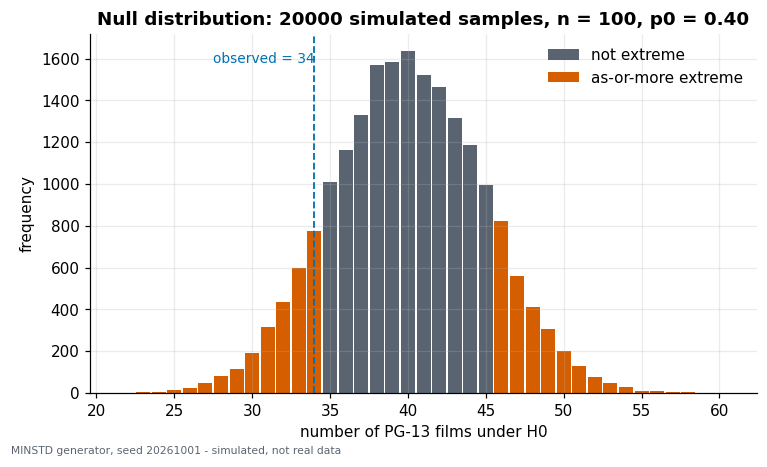

In [10]:
# --- Nol taqsimoti va keskin soha (Okabe–Ito, ASCII yorliqlar) --------
vals = np.arange(sim.min(), sim.max() + 1)
cnts = np.array([(sim == v).sum() for v in vals])
kesk = np.abs(vals - nobs * p0) >= dobs
fig, ax = plt.subplots()
ax.bar(vals[~kesk], cnts[~kesk], width=0.9, color=oiGrey, label="not extreme")
ax.bar(vals[kesk], cnts[kesk], width=0.9, color=oiVerm,
       label="as-or-more extreme")
ax.axvline(xobs, linestyle="--", color=oiBlue, linewidth=1.2)
ax.annotate("observed = 34", xy=(xobs, ax.get_ylim()[1] * 0.92),
            ha="right", color=oiBlue, fontsize=9)
ax.set_xlabel("number of PG-13 films under H0"); ax.set_ylabel("frequency")
ax.set_title("Null distribution: 20000 simulated samples, n = 100, p0 = 0.40")
ax.legend(frameon=False)
fig.text(0.01, 0.005, "MINSTD generator, seed 20261001 - simulated, not real data",
         fontsize=7, color=oiGrey)
plt.tight_layout(); plt.show()

In [11]:
# --- 2C: AYNI SAVOL, TOʻRT USUL --------------------------------------
pv_sim = float(keskin.mean())
# (2) Aniq binomial
pv_ex  = float(stats.binom.cdf(xobs, nobs, p0)
               + (1 - stats.binom.cdf(nobs * p0 + dobs - 1, nobs, p0)))
# (3) z-test. DIQQAT: maxrajda p_0, phat EMAS.
se0    = math.sqrt(p0 * (1 - p0) / nobs)
z0     = (phat - p0) / se0
pv_z   = float(p_z2(z0))
# (3b) z-test + uzluksizlik tuzatmasi (7-hafta)
zc     = (phat + 0.5 / nobs - p0) / se0
pv_zc  = float(p_z2(zc))

P_("")
P_("=== 2-TOPSHIRIQ (C): AYNI SAVOL, TOʻRT USUL ===")
P_("shart tekshiruvi: n*p_0 = %.1f >= 10 va n(1-p_0) = %.1f >= 10 -> %s",
   nobs * p0, nobs * (1 - p0), ha(nobs * p0 >= 10 and nobs * (1 - p0) >= 10))
P_("SE_0 = sqrt(0,40*0,60/100) = %.6f   (p_0 dan! phat dan EMAS)", se0)
P_("z    = (%.4f - %.2f)/%.6f = %.6f", phat, p0, se0, z0)
P_("z_tuzatilgan = (%.4f + %.3f - %.2f)/%.6f = %.6f",
   phat, 0.5 / nobs, p0, se0, zc)
P_("")
P_("%s%s%s", pad("usul", 30), padl("p-qiymat", 12),
   padl("aniqdan farq foizi", 22))
P_("%s%s%s", pad("simulyatsiya (20 000)", 30), padl("%.6f" % pv_sim, 12),
   padl("%+.2f" % ((pv_sim - pv_ex) / pv_ex * 100), 22))
P_("%s%s%s", pad("aniq binomial", 30), padl("%.6f" % pv_ex, 12),
   padl("--", 22))
P_("%s%s%s", pad("z-test (tuzatmasiz)", 30), padl("%.6f" % pv_z, 12),
   padl("%+.2f" % ((pv_z - pv_ex) / pv_ex * 100), 22))
P_("%s%s%s", pad("z-test + uzluksizlik tuzatmasi", 30),
   padl("%.6f" % pv_zc, 12),
   padl("%+.2f" % ((pv_zc - pv_ex) / pv_ex * 100), 22))
P_("")
P_("Tuzatmasiz z-test aniq qiymatdan %.1f foiz PAST; tuzatma bilan farq %.1f foiz.",
   abs(pv_z - pv_ex) / pv_ex * 100, abs(pv_zc - pv_ex) / pv_ex * 100)
P_("Bu -- 7-haftadagi uzluksizlik tuzatmasining AYNAN oʻsha roli:")
P_("X diskret, normal esa uzluksiz.")
P_("")
P_("--- Bir tomonlama test (agar savol 'kamroqmi?' boʻlsa) ---")
P_("aniq:  P(X <= %d | p=0,40) = %.6f", xobs,
   float(stats.binom.cdf(xobs, nobs, p0)))
P_("z ile: Phi(%.4f)          = %.6f", z0, float(stats.norm.cdf(z0)))
P_("simul: X <= %d ulushi     = %.6f", xobs, (sim <= xobs).mean())
P_("DIQQAT: yoʻnalish maʼlumotni KOʻRISHDAN OLDIN tanlanishi shart.")
P_("Keyin tanlash -- p-hacking (5-topshiriq).")
P_("")
P_("XULOSA: qaror alpha = 0,05 da -> %s",
   "H_0 RAD ETILADI" if pv_ex < 0.05 else "H_0 RAD ETILMAYDI")
P_("Effekt: phat - p_0 = %+.4f (%.1f foiz nisbiy)", phat - p0,
   (phat - p0) / p0 * 100)


=== 2-TOPSHIRIQ (C): AYNI SAVOL, TOʻRT USUL ===
shart tekshiruvi: n*p_0 = 40.0 >= 10 va n(1-p_0) = 60.0 >= 10 -> HA
SE_0 = sqrt(0,40*0,60/100) = 0.048990   (p_0 dan! phat dan EMAS)
z    = (0.3400 - 0.40)/0.048990 = -1.224745
z_tuzatilgan = (0.3400 + 0.005 - 0.40)/0.048990 = -1.122683

usul                              p-qiymat    aniqdan farq foizi
simulyatsiya (20 000)             0.261600                 +0.07
aniq binomial                     0.261427                    --
z-test (tuzatmasiz)               0.220671                -15.59
z-test + uzluksizlik tuzatmasi    0.261572                 +0.06

Tuzatmasiz z-test aniq qiymatdan 15.6 foiz PAST; tuzatma bilan farq 0.1 foiz.
Bu -- 7-haftadagi uzluksizlik tuzatmasining AYNAN oʻsha roli:
X diskret, normal esa uzluksiz.

--- Bir tomonlama test (agar savol 'kamroqmi?' boʻlsa) ---
aniq:  P(X <= 34 | p=0,40) = 0.130337
z ile: Phi(-1.2247)          = 0.110336
simul: X <= 34 ulushi     = 0.130650
DIQQAT: yoʻnalish maʼlumotni KOʻRISHDAN 

**Talqin.**

1. Simulyatsiya ($0{,}2616$) va aniq binomial ($0{,}2614$) farqi
   nechanchi xonada? Bu farq **Monte-Karlo xatosi** bilan izohlanadimi?
   ($\SE\approx\sqrt{p(1-p)/M}$ ni hisoblang.)
2. Tuzatmasiz $z$-test $15{,}6\,\%$ xato qildi. Bu xato **qaysi
   tomonga** — $p$ ni kattalashtirdimi yoki kichraytirdimi? Bu
   xavfliroqmi yoki xavfsizroqmi?
3. Nol taqsimotining SD si $4{,}8956$, nazariy qiymat $4{,}8990$.
   Uchinchi xonadagi farqni nima tushuntiradi?
4. Bir tomonlama $p$ ikki tomonlamaning taxminan yarmiga teng. Nima
   uchun **aynan** yarmi emas?
5. **Tuzoq.** «$p=0{,}26$ — demak $H_0$ toʻgʻri boʻlish ehtimoli
   $26\,\%$». Bu jumlaning qayeri xato? 3-haftadagi qaysi tushuncha
   bilan bogʻliq?

**Qaror.** Sizga «$z$-test tez, simulyatsiya sekin — nega umuman
simulyatsiya oʻrgatiladi?» degan savol berildi. Ikki sabab keltiring
va biriga bugungi jadvaldan **son** bilan dalil bering.

---

# 3-topshiriq. $H_0$ ostida $p$ tekis taqsimlangan {#t3}

> **Blum:** Tahlil · **Qiyinlik:** 4 (Analitik) · **Ball:** 16 ·
> **Vaqt:** 14 daqiqa

**Statistik tushuncha.** Bu — butun mavzuning kaliti va u
**isbotlanmaydi, oʻlchanadi**. Agar $H_0$ **toʻgʻri** boʻlsa,
$p$-qiymat $[0,1]$ da **tekis** taqsimlanadi:

$$H_0 \text{ toʻgʻri} \implies P \sim \mathrm{Unif}(0,1)
\implies \Prob(P<0{,}05)=0{,}05 .$$

Demak «$p<0{,}05$ chiqdi» degan xabar $H_0$ notoʻgʻri ekanini
**bildirmaydi**: $H_0$ toʻgʻri boʻlganda ham har $20$ testdan bittasi
shunday chiqadi. Butun 5-topshiriq shu bitta faktdan oʻsib chiqadi.

**Maʼlumot.** *Simulyatsiya qilingan* normal bosh toʻplam
$\Norm(0,1)$; $H_0:\mu=0$ **toʻgʻri**; har bir $n$ uchun $40\,000$ ta
$t$-test; urugʻ $20261100+n$.

**Kod.**

In [12]:
# --- 3A: H_0 TOʻGʻRI boʻlgan holda 40 000 ta test ---------------------
mm = 40000
P_("=== 3-TOPSHIRIQ: H_0 OSTIDA p TEKIS TAQSIMLANGAN ===")
P_("normal bosh toʻplam N(0,1); H_0: mu = 0 -- va u HAQIQATAN TOʻGʻRI")
P_("mm = %d ta test har bir n uchun; generator MINSTD, urugʻ 20261100+n", mm)
P_("")
P_("%s%s%s%s%s", padl("n", 5), padl("P(p<0,05)", 13), padl("P(p<0,01)", 13),
   padl("P(p<0,10)", 13), padl("Kolmogorov", 13))
psaqla = {}
for n2 in [5, 10, 30]:
    g  = minstd(20261100 + n2)
    Z  = minstd_norm(g, mm * n2).reshape(mm, n2)
    tt = qatorOrtacha(Z) / (np.sqrt(qatorVarS(Z)) / math.sqrt(n2))
    pv = p_t2(tt, n2 - 1)
    psaqla[n2] = pv
    P_("%s%s%s%s%s", padl("%d" % n2, 5),
       padl("%.5f" % (pv < 0.05).mean(), 13),
       padl("%.5f" % (pv < 0.01).mean(), 13),
       padl("%.5f" % (pv < 0.10).mean(), 13),
       padl("%.5f" % kolm(pv), 13))
    del Z, tt
P_("kutilgan qiymatlar:      0,05000      0,01000      0,10000     -> 0")
P_("")
P_("n = 30 uchun 20 ta teng kenglikdagi katakcha (har birida ~2000 kutiladi):")
pv30 = psaqla[30]
kat = [int(((pv30 >= (j - 1) / 20) & (pv30 < j / 20)).sum())
       for j in range(1, 21)]
for blok in range(4):
    s = ""
    for k in range(1, 6):
        s = s + padl("%d" % kat[blok * 5 + k - 1], 8)
    P_("  [%.2f-%.2f)%s", blok * 0.25, (blok + 1) * 0.25, s)
P_("")
P_("eng kichik katakcha = %d, eng katta = %d, oʻrtacha = %.1f",
   min(kat), max(kat), mm / 20)
P_("")
P_("XULOSA: H_0 toʻgʻri boʻlsa, p hech qanday qiymatni afzal koʻrmaydi.")
P_("Demak 'p kichik chiqdi' -- H_0 notoʻgʻri degani EMAS.")
P_("20 tadan bittasi H_0 TOʻGʻRI boʻlganda ham 'ahamiyatli' chiqadi.")

=== 3-TOPSHIRIQ: H_0 OSTIDA p TEKIS TAQSIMLANGAN ===
normal bosh toʻplam N(0,1); H_0: mu = 0 -- va u HAQIQATAN TOʻGʻRI
mm = 40000 ta test har bir n uchun; generator MINSTD, urugʻ 20261100+n

    n    P(p<0,05)    P(p<0,01)    P(p<0,10)   Kolmogorov
    5      0.04820      0.01002      0.09663      0.00394


   10      0.05040      0.01018      0.10025      0.00578


   30      0.04810      0.00932      0.09872      0.00549
kutilgan qiymatlar:      0,05000      0,01000      0,10000     -> 0

n = 30 uchun 20 ta teng kenglikdagi katakcha (har birida ~2000 kutiladi):
  [0.00-0.25)    1924    2025    1978    1918    1987
  [0.25-0.50)    1991    1996    2036    1972    2085
  [0.50-0.75)    1984    2003    1937    2035    1956
  [0.75-1.00)    2015    2058    2012    2052    2036

eng kichik katakcha = 1918, eng katta = 2085, oʻrtacha = 2000.0

XULOSA: H_0 toʻgʻri boʻlsa, p hech qanday qiymatni afzal koʻrmaydi.
Demak 'p kichik chiqdi' -- H_0 notoʻgʻri degani EMAS.
20 tadan bittasi H_0 TOʻGʻRI boʻlganda ham 'ahamiyatli' chiqadi.


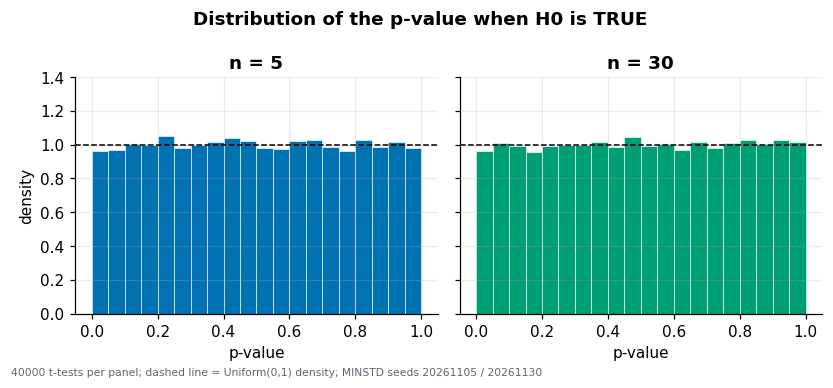

In [13]:
# --- p-qiymat gistogrammalari: n = 5 va n = 30 ------------------------
fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.4), sharey=True)
for ax, n2, col in zip(axes, [5, 30], [oiBlue, oiGreen]):
    ax.hist(psaqla[n2], bins=20, range=(0, 1), density=True,
            color=col, edgecolor="white", linewidth=0.4)
    ax.axhline(1.0, linestyle="--", color="black", linewidth=1.0)
    ax.set_title("n = %d" % n2); ax.set_xlabel("p-value"); ax.set_ylim(0, 1.4)
axes[0].set_ylabel("density")
fig.suptitle("Distribution of the p-value when H0 is TRUE", fontweight="bold")
fig.text(0.01, 0.005,
         "40000 t-tests per panel; dashed line = Uniform(0,1) density; "
         "MINSTD seeds 20261105 / 20261130", fontsize=7, color=oiGrey)
plt.tight_layout(); plt.show()

**Talqin.**

1. Uchta $n$ uchun ham $\Prob(p<0{,}05)\approx0{,}05$. Bu **nimani**
   isbotlaydi va nimani **isbotlamaydi**?
2. Kolmogorov masofasi $n$ bilan tizimli ravishda kamayadimi? Agar
   yoʻq boʻlsa — nima uchun? ($40\,000$ ta kuzatuv uchun kutilgan
   masofa $\approx1{,}36/\sqrt{40000}$ ni hisoblang.)
3. 20 ta katakchaning eng kichigi va eng kattasi orasidagi farq
   tasodifiy tebranish bilan izohlanadimi? (Har bir katakcha uchun
   $\SD\approx\sqrt{mm\cdot0{,}05\cdot0{,}95}$.)
4. Agar $H_0$ **notoʻgʻri** boʻlsa, gistogramma qanday koʻrinadi?
   Bashoratingizni **hozir** yozib qoʻying — 4-topshiriqda
   tekshiramiz.
5. Bu natija «$\alpha=0{,}05$ ni tanlash» degan qarorga qanday maʼno
   beradi? $\alpha$ — bu aslida **nima**ning nomi?

**Qaror.** Jurnal muharriri sizga «faqat $p<0{,}05$ boʻlgan
maqolalarni chop etamiz» deydi. Yuqoridagi jadvalga tayanib, bu
siyosat adabiyotga qanday taʼsir qilishini tushuntiring. (Bu — *nashr
siljishi*, ingliz tilida *publication bias*.)

---

# 4-topshiriq. I va II tur xatolari va quvvat {#t4}

> **Blum:** Tahlil · **Qiyinlik:** 4 (Analitik) · **Ball:** 16 ·
> **Vaqt:** 16 daqiqa

**Statistik tushuncha.**

| | $H_0$ toʻgʻri | $H_0$ notoʻgʻri |
|---|---|---|
| **rad etildi** | **I tur xatosi** ($\alpha$) | toʻgʻri qaror ($1-\beta$) |
| **rad etilmadi** | toʻgʻri qaror | **II tur xatosi** ($\beta$) |

$$\text{Quvvat}=1-\beta=\Prob(\text{rad etish}\mid H_0\ \text{notoʻgʻri}).$$

Quvvat **uch** narsaga bogʻliq: effekt hajmi $\delta$, tanlanma hajmi
$n$ va $\alpha$. Va u **tadqiqotdan oldin** hisoblanadi — keyin emas.

$$n \ \ge\ \left(\frac{z_{1-\alpha/2}+z_{1-\beta}}{d}\right)^{2},
\qquad d=\frac{\delta}{\sigma}\ \ (\text{Koen } d).$$

**Maʼlumot.** **FARAZIY** model (haqiqiy maʼlumot emas, oʻquv
maqsadida tuzilgan): $\sigma=12$ **maʼlum**, $H_0:\mu=100$,
$H_1:\mu\ne100$, $\alpha=0{,}05$.

**Kod.**

In [14]:
# --- 4A: quvvat jadvali (nazariy, simulyatsiyasiz) --------------------
# sigma MAʼLUM deb olinadi -> z-test. Quvvat formulasi:
#   quvvat = Phi(-z_krit + d) + Phi(-z_krit - d),  d = (mu_1 - mu_0)/SE
sg = 12.0; mu0d = 100.0

def quvvat(mu1, n, alpha):
    se = sg / np.sqrt(n); zk = stats.norm.ppf(1 - alpha / 2)
    d = (np.asarray(mu1, dtype=float) - mu0d) / se
    return stats.norm.cdf(-zk + d) + stats.norm.cdf(-zk - d)

P_("=== 4-TOPSHIRIQ: XATOLAR VA QUVVAT ===")
P_("FARAZIY model: sigma = 12 maʼlum, H_0: mu = 100, alpha = 0,05")
P_("(bu sonlar oʻquv maqsadida tanlangan, rasmiy statistika EMAS)")
P_("")
P_("%s%s%s%s%s%s", padl("n", 6), padl("SE", 9),
   padl("rad qilish chegarasi", 24), padl("quvvat mu=103", 15),
   padl("quvvat mu=106", 15), padl("quvvat mu=110", 15))
for n2 in [9, 16, 25, 36, 64, 100, 200]:
    se = sg / math.sqrt(n2); kr = Z975 * se
    P_("%s%s%s%s%s%s", padl("%d" % n2, 6), padl("%.4f" % se, 9),
       padl("100 +- %.4f" % kr, 24),
       padl("%.4f" % float(quvvat(103, n2, 0.05)), 15),
       padl("%.4f" % float(quvvat(106, n2, 0.05)), 15),
       padl("%.4f" % float(quvvat(110, n2, 0.05)), 15))
P_("")
P_("--- 80 foiz quvvatga erishish uchun kerakli n ---")
P_("%s%s%s", padl("effekt delta", 14), padl("Koen d", 12), padl("kerakli n", 12))
for delta in [2, 3, 4, 6, 8, 12]:
    d = delta / sg
    P_("%s%s%s", padl("%.1f" % delta, 14), padl("%.4f" % d, 12),
       padl("%d" % math.ceil(((Z975 + Z80) / d) ** 2), 12))
P_("Effekt IKKI barobar kichraysa, n TOʻRT barobar oshadi -- sqrt(n) qonuni.")
P_("")
P_("--- alpha va beta OʻZARO ALMASHTIRILADI (n = 36, mu = 106) ---")
P_("%s%s%s%s", padl("alpha", 9), padl("z_krit", 11), padl("quvvat", 11),
   padl("beta", 11))
for al in [0.10, 0.05, 0.01, 0.001]:
    pw = float(quvvat(106, 36, al))
    P_("%s%s%s%s", padl("%.3f" % al, 9),
       padl("%.4f" % float(stats.norm.ppf(1 - al / 2)), 11),
       padl("%.4f" % pw, 11), padl("%.4f" % (1 - pw), 11))
P_("alpha ni kichraytirish I tur xatosini kamaytiradi, II turnikini OSHIRADI.")
P_("Bepul tushadigan narsa yoʻq -- faqat n ni oshirish ikkalasini yaxshilaydi.")

=== 4-TOPSHIRIQ: XATOLAR VA QUVVAT ===
FARAZIY model: sigma = 12 maʼlum, H_0: mu = 100, alpha = 0,05
(bu sonlar oʻquv maqsadida tanlangan, rasmiy statistika EMAS)

     n       SE    rad qilish chegarasi  quvvat mu=103  quvvat mu=106  quvvat mu=110
     9   4.0000           100 +- 7.8399         0.1165         0.3230         0.7054
    16   3.0000           100 +- 5.8799         0.1701         0.5160         0.9152
    25   2.4000           100 +- 4.7039         0.2395         0.7054         0.9863
    36   2.0000           100 +- 3.9199         0.3230         0.8508         0.9988
    64   1.5000           100 +- 2.9399         0.5160         0.9793         1.0000
   100   1.2000           100 +- 2.3520         0.7054         0.9988         1.0000
   200   0.8485           100 +- 1.6631         0.9424         1.0000         1.0000

--- 80 foiz quvvatga erishish uchun kerakli n ---
  effekt delta      Koen d   kerakli n
           2.0      0.1667         283
           3.0      0.2500 

In [15]:
# --- 4B: nazariy quvvatni SIMULYATSIYA bilan tekshiramiz --------------
# Nazariya n=36, mu=106 uchun 0,8508 deydi. Endi shu dunyoni YARATAMIZ.
msim = 20000; n4 = 36
# (i) H_0 TOʻGʻRI boʻlgan dunyo -> I tur xatosini oʻlchaymiz
g  = minstd(20261037)
Z0 = minstd_norm(g, msim * n4).reshape(msim, n4)
xb0 = 100 + sg * qatorOrtacha(Z0)
z0s = (xb0 - mu0d) / (sg / math.sqrt(n4))
# (ii) H_0 NOTOʻGʻRI (haqiqiy mu = 106) -> quvvatni oʻlchaymiz
g  = minstd(20261036)
Z1 = minstd_norm(g, msim * n4).reshape(msim, n4)
xb1s = 106 + sg * qatorOrtacha(Z1)
z1s = (xb1s - mu0d) / (sg / math.sqrt(n4))

P_("")
P_("--- 4B: nazariyani simulyatsiya bilan tekshirish (urugʻ 20261037/20261036) ---")
P_("%d ta takror, n = %d, sigma = %.0f, alpha = 0,05", msim, n4, sg)
P_("")
P_("%s%s%s%s", pad("dunyo", 26), padl("rad etildi", 13),
   padl("kuzatilgan", 13), padl("nazariy", 12))
P_("%s%s%s%s", pad("H_0 TOʻGʻRI (mu = 100)", 26),
   padl("%d" % int((np.abs(z0s) > Z975).sum()), 13),
   padl("%.4f" % (np.abs(z0s) > Z975).mean(), 13),
   padl("%.4f" % 0.05, 12))
P_("%s%s%s%s", pad("H_0 NOTOʻGʻRI (mu = 106)", 26),
   padl("%d" % int((np.abs(z1s) > Z975).sum()), 13),
   padl("%.4f" % (np.abs(z1s) > Z975).mean(), 13),
   padl("%.4f" % float(quvvat(106, n4, 0.05)), 12))
P_("")
P_("Birinchi satr -- I TUR XATOSI (alpha). Ikkinchi satr -- QUVVAT (1-beta).")
P_("II tur xatosi beta = %.4f: haqiqiy farq BOR, ammo biz uni koʻra olmadik.",
   1 - (np.abs(z1s) > Z975).mean())
P_("")
P_("3-topshiriqdagi bashoratingizni tekshiramiz: H_0 NOTOʻGʻRI boʻlganda")
P_("p-qiymat qanday taqsimlanadi?")
pv1 = p_z2(z1s)
P_("%s%s%s", padl("soha", 14), padl("H_0 toʻgʻri", 14), padl("H_0 notoʻgʻri", 16))
for lim in [0.01, 0.05, 0.10, 0.50]:
    P_("%s%s%s", padl("p < %.2f" % lim, 14),
       padl("%.4f" % (p_z2(z0s) < lim).mean(), 14),
       padl("%.4f" % (pv1 < lim).mean(), 16))
P_("H_0 toʻgʻri -> TEKIS. H_0 notoʻgʻri -> nolga QIYSHIQ. Farq shu.")
del Z0, Z1


--- 4B: nazariyani simulyatsiya bilan tekshirish (urugʻ 20261037/20261036) ---
20000 ta takror, n = 36, sigma = 12, alpha = 0,05

dunyo                        rad etildi   kuzatilgan     nazariy
H_0 TOʻGʻRI (mu = 100)              982       0.0491      0.0500
H_0 NOTOʻGʻRI (mu = 106)          17093       0.8547      0.8508

Birinchi satr -- I TUR XATOSI (alpha). Ikkinchi satr -- QUVVAT (1-beta).
II tur xatosi beta = 0.1453: haqiqiy farq BOR, ammo biz uni koʻra olmadik.

3-topshiriqdagi bashoratingizni tekshiramiz: H_0 NOTOʻGʻRI boʻlganda
p-qiymat qanday taqsimlanadi?
          soha   H_0 toʻgʻri   H_0 notoʻgʻri
      p < 0.01        0.0102          0.6706
      p < 0.05        0.0491          0.8547
      p < 0.10        0.0988          0.9126
      p < 0.50        0.4974          0.9907
H_0 toʻgʻri -> TEKIS. H_0 notoʻgʻri -> nolga QIYSHIQ. Farq shu.


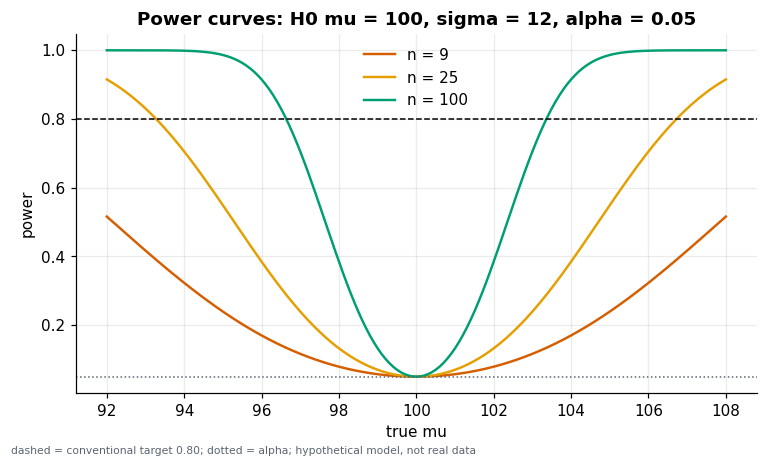

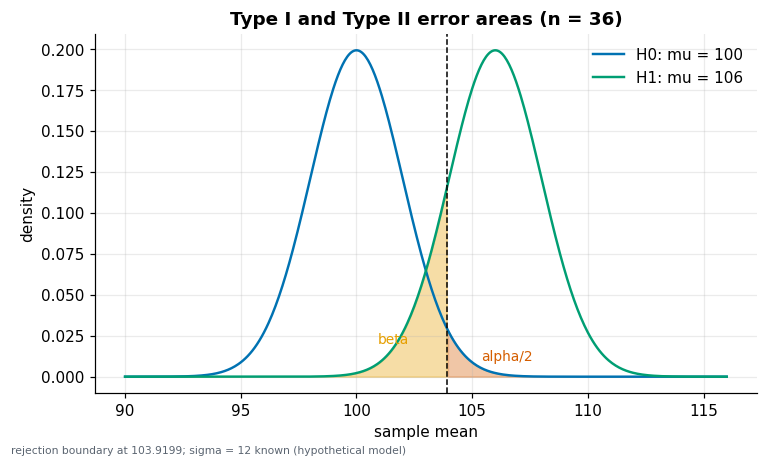

In [16]:
# --- Quvvat egri chiziqlari va ikki zichlik (alpha/beta) --------------
mus = np.arange(92, 108.001, 0.1)
fig, ax = plt.subplots()
for n2, col in zip([9, 25, 100], [oiVerm, oiOrange, oiGreen]):
    ax.plot(mus, quvvat(mus, n2, 0.05), color=col, linewidth=1.6,
            label="n = %d" % n2)
ax.axhline(0.8, linestyle="--", color="black", linewidth=1.0)
ax.axhline(0.05, linestyle=":", color=oiGrey, linewidth=1.0)
ax.set_xlabel("true mu"); ax.set_ylabel("power")
ax.set_title("Power curves: H0 mu = 100, sigma = 12, alpha = 0.05")
ax.legend(frameon=False)
fig.text(0.01, 0.005,
         "dashed = conventional target 0.80; dotted = alpha; "
         "hypothetical model, not real data", fontsize=7, color=oiGrey)
plt.tight_layout(); plt.show()

xs = np.arange(90, 116.001, 0.05); se4 = sg / 6.0; kr4 = mu0d + Z975 * se4
d0 = stats.norm.pdf(xs, 100, se4); d1 = stats.norm.pdf(xs, 106, se4)
fig, ax = plt.subplots()
ax.fill_between(xs, 0, d0, where=(xs >= kr4), color=oiVerm, alpha=0.35)
ax.fill_between(xs, 0, d1, where=(xs <= kr4), color=oiOrange, alpha=0.35)
ax.plot(xs, d0, color=oiBlue, linewidth=1.6, label="H0: mu = 100")
ax.plot(xs, d1, color=oiGreen, linewidth=1.6, label="H1: mu = 106")
ax.axvline(kr4, linestyle="--", color="black", linewidth=1.0)
ax.annotate("alpha/2", xy=(105.4, 0.010), color=oiVerm, fontsize=9)
ax.annotate("beta", xy=(100.9, 0.020), color=oiOrange, fontsize=9)
ax.set_xlabel("sample mean"); ax.set_ylabel("density")
ax.set_title("Type I and Type II error areas (n = 36)")
ax.legend(frameon=False)
fig.text(0.01, 0.005, "rejection boundary at %.4f; sigma = 12 known "
         "(hypothetical model)" % kr4, fontsize=7, color=oiGrey)
plt.tight_layout(); plt.show()

**Talqin.**

1. $n=9$ dan $n=200$ ga oʻtganda $\mu=103$ dagi quvvat qanday oʻzgardi?
   Bu oʻsish **chiziqlimi**?
2. Simulyatsiya nazariy $0{,}8508$ ni tasdiqladimi? Farqni Monte-Karlo
   xatosi ($1{,}96\sqrt{pq/m}$) bilan solishtiring.
3. $\alpha$ ni $0{,}05$ dan $0{,}001$ ga tushirsangiz quvvat qanchaga
   tushadi? **Qaysi holatda** bunday almashtirish oqilona?
4. 3-topshiriqdagi bashoratingiz toʻgʻri chiqdimi? $H_0$ notoʻgʻri
   boʻlganda $p$ ning taqsimoti qanday oʻzgardi?
5. Effekt $\delta=2$ uchun $n=283$ kerak. Agar byudjetingiz $n=100$ ga
   yetsa, **nima qilasiz**? Uchta variantni sanang va har birining
   narxini ayting.

**Qaror.** Sizdan «$n=25$ bilan tadqiqot oʻtkazamiz, kutilayotgan
effekt $d=0{,}25$» degan reja tasdiqlashingiz soʻraldi. Rejani
tasdiqlaysizmi? Javobingizni **jadvaldagi son** bilan asoslang va
muqobil taklif bering.

---

# 5-topshiriq. $p$-hacking laboratoriyasi {#t5}

> **Blum:** Baholash · **Qiyinlik:** 5 (Ilgʻor) · **Ball:** 26 ·
> **Vaqt:** 28 daqiqa

**Statistik tushuncha.** 3-topshiriqda oʻlchadingiz: $H_0$ toʻgʻri
boʻlsa ham har $20$ testdan bittasi «ahamiyatli» chiqadi. Bu haqiqat
suiisteʼmol qilinishi mumkin — va u **muntazam ravishda** suiisteʼmol
qilinadi. Bugun siz **oʻzingiz** suiisteʼmolchi boʻlasiz va zararni
**oʻz sonlaringiz bilan** oʻlchaysiz.

Uchta shakl:

* **Koʻp test.** $m$ ta bogʻliqsiz test oʻtkazing, eng yaxshisini
  eʼlon qiling: $\Prob(\text{kamida bitta } p<0{,}05)=1-0{,}95^{m}$.
* **Toʻxtash qoidasini buzish.** Har bir yangi kuzatuvdan keyin
  testni qaytaring, $p<0{,}05$ boʻlishi bilan toʻxtang.
* **Kichik guruhlar boʻyicha izlash.** Umumiy test ishlamasa,
  maʼlumotni ahamiyatsiz belgilar boʻyicha boʻlib qayta tekshiring.

**Har uchala tajribada $H_0$ HAR DOIM TOʻGʻRI.** Maʼlumot — **sof
shovqin**, $\Norm(0,1)$. Topilgan har bir «kashfiyot» — yolgʻon.

**Kod.**

In [17]:
# --- 5A: KOʻP TEST -----------------------------------------------------
# m ta MUSTAQIL test (har birida yangi maʼlumot), H_0 hamma joyda toʻgʻri.
P_("=== 5-TOPSHIRIQ (A): KOʻP TEST ===")
P_("%s%s", padl("testlar soni m", 16), padl("1 - 0,95^m", 14))
for mtst in [1, 2, 5, 10, 14, 20, 50, 100]:
    P_("%s%s", padl("%d" % mtst, 16), padl("%.6f" % (1 - 0.95 ** mtst), 14))
P_("")
P_("Endi buni SIMULYATSIYA bilan tekshiramiz (urugʻ 20261200).")
P_("20 000 ta 'tadqiqot'; har birida m=20 ta test, n=30, SOF SHOVQIN.")
g = minstd(20261200); sims = 20000; mtest = 20; nn = 30
cnt = 0; nsig = np.zeros(sims, dtype=int)
for r in range(sims):
    Z  = minstd_norm(g, mtest * nn).reshape(mtest, nn)
    tt = qatorOrtacha(Z) / (np.sqrt(qatorVarS(Z)) / math.sqrt(nn))
    k  = int((p_t2(tt, nn - 1) < 0.05).sum())
    nsig[r] = k
    if k > 0:
        cnt = cnt + 1
P_("kamida bitta 'ahamiyatli' natija chiqqan tadqiqotlar: %d/%d = %.4f",
   cnt, sims, cnt / sims)
P_("nazariy 1 - 0,95^20 = %.4f -> MOS KELDI (testlar MUSTAQIL edi)",
   1 - 0.95 ** 20)
P_("")
P_("20 ta testdan nechtasi 'ahamiyatli' chiqdi:")
P_("%s%s%s", padl("ahamiyatli soni", 17), padl("tadqiqotlar", 13),
   padl("ulush", 11))
for k in range(5):
    P_("%s%s%s", padl("%d" % k, 17), padl("%d" % int((nsig == k).sum()), 13),
       padl("%.4f" % (nsig == k).mean(), 11))
P_("%s%s%s", padl("5 va koʻproq", 17), padl("%d" % int((nsig >= 5).sum()), 13),
   padl("%.4f" % (nsig >= 5).mean(), 11))
P_("oʻrtacha 'ahamiyatli' testlar soni = %.4f (nazariy 20*0,05 = 1,0)",
   nsig.mean())

=== 5-TOPSHIRIQ (A): KOʻP TEST ===
  testlar soni m    1 - 0,95^m
               1      0.050000
               2      0.097500
               5      0.226219
              10      0.401263
              14      0.512325
              20      0.641514
              50      0.923055
             100      0.994079

Endi buni SIMULYATSIYA bilan tekshiramiz (urugʻ 20261200).
20 000 ta 'tadqiqot'; har birida m=20 ta test, n=30, SOF SHOVQIN.


kamida bitta 'ahamiyatli' natija chiqqan tadqiqotlar: 12822/20000 = 0.6411
nazariy 1 - 0,95^20 = 0.6415 -> MOS KELDI (testlar MUSTAQIL edi)

20 ta testdan nechtasi 'ahamiyatli' chiqdi:
  ahamiyatli soni  tadqiqotlar      ulush
                0         7178     0.3589
                1         7589     0.3795
                2         3689     0.1845
                3         1211     0.0605
                4          279     0.0140
     5 va koʻproq           54     0.0027
oʻrtacha 'ahamiyatli' testlar soni = 0.9999 (nazariy 20*0,05 = 1,0)


In [18]:
# --- 5B: TOʻXTASH QOIDASINI BUZISH ------------------------------------
# Tadqiqotchi n=10 dan boshlab HAR BIR yangi kuzatuvdan keyin testni
# qaytaradi va p<0,05 boʻlishi bilan toʻxtaydi. H_0 HAR DOIM TOʻGʻRI.
# TEZLIK QOIDASI: ichma-ich sikl OʻRNIGA kumulyativ yigʻindilar.
P_("")
P_("=== 5-TOPSHIRIQ (B): TOʻXTASH QOIDASINI BUZISH ===")
P_("urugʻ 20261300; har bir chegara uchun 5 000 ta 'tadqiqotchi'")
P_("H_0 HAR DOIM TOʻGʻRI -- topilgan har bir natija YOLGʻON")
P_("")
P_("%s%s%s%s", padl("n oraligʻi", 14), padl("haqiqiy I tur xatosi", 22),
   padl("eʼlon qilingan", 16), padl("necha barobar", 15))
g = minstd(20261300); sims2 = 5000
toxtash = None
for nmax in [30, 50, 100, 200]:
    hit = 0; qachon = []
    for r in range(sims2):
        z   = minstd_norm(g, nmax)
        cs  = np.cumsum(z); cs2 = np.cumsum(z * z)
        j   = np.arange(10, nmax + 1)
        mn  = cs[j - 1] / j
        va  = (cs2[j - 1] - j * mn * mn) / (j - 1)
        tt  = mn / np.sqrt(va / j)
        pv  = p_t2(tt, j - 1)
        w   = np.flatnonzero(pv < 0.05)
        if len(w) > 0:
            hit = hit + 1; qachon.append(int(j[w[0]]))
    if nmax == 200:
        toxtash = np.array(qachon, dtype=float)
    P_("%s%s%s%s", padl("10 -> %d" % nmax, 14),
       padl("%.4f" % (hit / sims2), 22), padl("0,0500", 16),
       padl("%.1f" % (hit / sims2 / 0.05), 15))
P_("")
P_("n = 200 gacha tekshirilganda toʻxtash nuqtasi (yolgʻon 'kashfiyot' joyi):")
P_("median n = %.1f · birinchi kvartil = %.1f · uchinchi kvartil = %.1f",
   float(np.median(toxtash)),
   float(np.quantile(toxtash, 0.25, method="linear")),
   float(np.quantile(toxtash, 0.75, method="linear")))
P_("n <= 30 da toʻxtaganlar ulushi = %.4f", (toxtash <= 30).mean())
P_("Yaʼni yolgʻon natijalarning deyarli yarmi n <= 30 da topiladi -- va")
P_("tadqiqotchi 'maʼlumot yetarli boʻldi' deb toʻxtaydi. Aynan shu -- tuzoq.")


=== 5-TOPSHIRIQ (B): TOʻXTASH QOIDASINI BUZISH ===
urugʻ 20261300; har bir chegara uchun 5 000 ta 'tadqiqotchi'
H_0 HAR DOIM TOʻGʻRI -- topilgan har bir natija YOLGʻON

    n oraligʻi  haqiqiy I tur xatosi  eʼlon qilingan  necha barobar


      10 -> 30                0.1720          0,0500            3.4


      10 -> 50                0.2232          0,0500            4.5


     10 -> 100                0.2822          0,0500            5.6


     10 -> 200                0.3476          0,0500            7.0

n = 200 gacha tekshirilganda toʻxtash nuqtasi (yolgʻon 'kashfiyot' joyi):
median n = 31.0 · birinchi kvartil = 13.0 · uchinchi kvartil = 80.8
n <= 30 da toʻxtaganlar ulushi = 0.4971
Yaʼni yolgʻon natijalarning deyarli yarmi n <= 30 da topiladi -- va
tadqiqotchi 'maʼlumot yetarli boʻldi' deb toʻxtaydi. Aynan shu -- tuzoq.


In [19]:
# --- 5C: KICHIK GURUHLAR BOʻYICHA IZLASH ------------------------------
# Umumiy test + 4 ta AHAMIYATSIZ belgi boʻyicha ikkiga boʻlish
# = 1 + 8 = 9 ta test, hammasi AYNI maʼlumot ustida.
P_("")
P_("=== 5-TOPSHIRIQ (C): KICHIK GURUHLAR BOʻYICHA IZLASH ===")
P_("urugʻ 20261400; 20 000 ta takror; n = 40; SOF SHOVQIN")
P_("1 ta umumiy test + 4 ta belgi x 2 ta yarim = 9 ta test")
g = minstd(20261400); sims3 = 20000
hit3 = 0; nsig3 = np.zeros(sims3, dtype=int)
tU = np.zeros(sims3); tA = np.full(sims3, np.nan); tB = np.full(sims3, np.nan)
for r in range(sims3):
    z   = minstd_norm(g, 40)
    lab = (g(4 * 40) < 0.5).reshape(4, 40)
    tv  = [z.mean() / (sdS(z) / math.sqrt(40))]; dv = [39]
    tU[r] = tv[0]
    for q in range(4):
        for val in [False, True]:
            sub = z[lab[q] == val]
            if len(sub) >= 5:
                tv.append(sub.mean() / (sdS(sub) / math.sqrt(len(sub))))
                dv.append(len(sub) - 1)
    ps = p_t2(np.array(tv), np.array(dv))
    k  = int((ps < 0.05).sum()); nsig3[r] = k
    if k > 0:
        hit3 = hit3 + 1
    # 1-belgining ikki yarmi -- bogʻliqlikni oʻlchash uchun saqlaymiz
    yarimA = z[~lab[0]]; yarimB = z[lab[0]]
    if len(yarimA) >= 5:
        tA[r] = yarimA.mean() / (sdS(yarimA) / math.sqrt(len(yarimA)))
    if len(yarimB) >= 5:
        tB[r] = yarimB.mean() / (sdS(yarimB) / math.sqrt(len(yarimB)))
P_("")
P_("kamida bitta 'ahamiyatli' chiqqan takrorlar: %d/%d = %.4f",
   hit3, sims3, hit3 / sims3)
P_("agar 9 ta test MUSTAQIL boʻlganda: 1 - 0,95^9 = %.6f", 1 - 0.95 ** 9)
P_("eʼlon qilingan daraja 0,05 ga nisbatan: %.1f barobar",
   hit3 / sims3 / 0.05)
P_("")
P_("DIQQAT: simulyatsiya nazariy %.4f dan PAST chiqdi.", 1 - 0.95 ** 9)
P_("Bu XATO EMAS. Sababini oʻzingiz topasiz -- quyidagi ikki oʻlchov yordam beradi:")
yaxshi = (~np.isnan(tA)) & (~np.isnan(tB))
P_("  korrelyatsiya(umumiy test t, 1-belgi 1-yarim t) = %+.4f",
   float(np.corrcoef(tU[yaxshi], tA[yaxshi])[0, 1]))
P_("  korrelyatsiya(1-belgi 1-yarim t, 1-belgi 2-yarim t) = %+.4f",
   float(np.corrcoef(tA[yaxshi], tB[yaxshi])[0, 1]))
P_("  oʻrtacha 'ahamiyatli' testlar soni (9 tadan) = %.4f", nsig3.mean())
P_("  agar bogʻliqsiz boʻlganda kutilar edi: 9*0,05 = 0,4500")


=== 5-TOPSHIRIQ (C): KICHIK GURUHLAR BOʻYICHA IZLASH ===
urugʻ 20261400; 20 000 ta takror; n = 40; SOF SHOVQIN
1 ta umumiy test + 4 ta belgi x 2 ta yarim = 9 ta test



kamida bitta 'ahamiyatli' chiqqan takrorlar: 5248/20000 = 0.2624
agar 9 ta test MUSTAQIL boʻlganda: 1 - 0,95^9 = 0.369751
eʼlon qilingan daraja 0,05 ga nisbatan: 5.2 barobar

DIQQAT: simulyatsiya nazariy 0.3698 dan PAST chiqdi.
Bu XATO EMAS. Sababini oʻzingiz topasiz -- quyidagi ikki oʻlchov yordam beradi:
  korrelyatsiya(umumiy test t, 1-belgi 1-yarim t) = +0.7038
  korrelyatsiya(1-belgi 1-yarim t, 1-belgi 2-yarim t) = +0.0094
  oʻrtacha 'ahamiyatli' testlar soni (9 tadan) = 0.4545
  agar bogʻliqsiz boʻlganda kutilar edi: 9*0,05 = 0,4500


In [20]:
# --- 5D: NAZORAT TAJRIBASI -- 9 ta HAQIQATAN MUSTAQIL test ------------
# 5C dagi 9 ta test bir xil maʼlumotdan hisoblangan edi. Endi AYNI 9 ta
# testni har biriga YANGI maʼlumot berib takrorlaymiz. Agar bogʻliqlik
# haqiqatan sabab boʻlsa, natija 1-0,95^9 ga QAYTISHI kerak.
P_("")
P_("=== 5-TOPSHIRIQ (D): NAZORAT -- 9 TA MUSTAQIL TEST ===")
P_("urugʻ 20261450; 20 000 ta takror; har bir test uchun YANGI n=40 tanlanma")
g = minstd(20261450); hit4 = 0
for r in range(20000):
    Z  = minstd_norm(g, 9 * 40).reshape(9, 40)
    tt = qatorOrtacha(Z) / (np.sqrt(qatorVarS(Z)) / math.sqrt(40))
    if (p_t2(tt, 39) < 0.05).any():
        hit4 = hit4 + 1
P_("kamida bitta 'ahamiyatli': %.4f   ·   nazariy 1-0,95^9 = %.4f",
   hit4 / 20000, 1 - 0.95 ** 9)
P_("MOS KELDI -> demak 5C dagi past qiymatning sababi BOGʻLIQLIK edi.")
P_("")
P_("=== 5-TOPSHIRIQ (E): YECHIM -- BONFERRONI VA OLDINDAN QAYD ETISH ===")
P_("Bonferroni: har bir test uchun alpha/m ishlatilsin.")
P_("%s%s%s", padl("m", 6), padl("alpha/m", 12), padl("umumiy I tur xatosi", 22))
for mtst in [5, 10, 20, 50]:
    P_("%s%s%s", padl("%d" % mtst, 6), padl("%.6f" % (0.05 / mtst), 12),
       padl("%.6f" % (1 - (1 - 0.05 / mtst) ** mtst), 22))
P_("Bonferroni umumiy xatoni 0,05 atrofida ushlaydi (biroz konservativ).")
P_("Batafsili -- 11-haftada (koʻp taqqoslash).")
P_("")
P_("AMMO Bonferroni 5B (toʻxtash) va 5C (izlash) ni TUZATMAYDI:")
P_("u faqat testlar SONI oldindan maʼlum boʻlganda ishlaydi.")
P_("Yagona toʻliq himoya -- OLDINDAN QAYD ETISH (preregistration):")
P_("gipoteza, n, alpha, yoʻnalish va tahlil rejasi maʼlumot")
P_("yigʻilishidan OLDIN yoziladi va oʻzgartirilmaydi.")


=== 5-TOPSHIRIQ (D): NAZORAT -- 9 TA MUSTAQIL TEST ===
urugʻ 20261450; 20 000 ta takror; har bir test uchun YANGI n=40 tanlanma


kamida bitta 'ahamiyatli': 0.3670   ·   nazariy 1-0,95^9 = 0.3698
MOS KELDI -> demak 5C dagi past qiymatning sababi BOGʻLIQLIK edi.

=== 5-TOPSHIRIQ (E): YECHIM -- BONFERRONI VA OLDINDAN QAYD ETISH ===
Bonferroni: har bir test uchun alpha/m ishlatilsin.
     m     alpha/m   umumiy I tur xatosi
     5    0.010000              0.049010
    10    0.005000              0.048890
    20    0.002500              0.048830
    50    0.001000              0.048794
Bonferroni umumiy xatoni 0,05 atrofida ushlaydi (biroz konservativ).
Batafsili -- 11-haftada (koʻp taqqoslash).

AMMO Bonferroni 5B (toʻxtash) va 5C (izlash) ni TUZATMAYDI:
u faqat testlar SONI oldindan maʼlum boʻlganda ishlaydi.
Yagona toʻliq himoya -- OLDINDAN QAYD ETISH (preregistration):
gipoteza, n, alpha, yoʻnalish va tahlil rejasi maʼlumot
yigʻilishidan OLDIN yoziladi va oʻzgartirilmaydi.


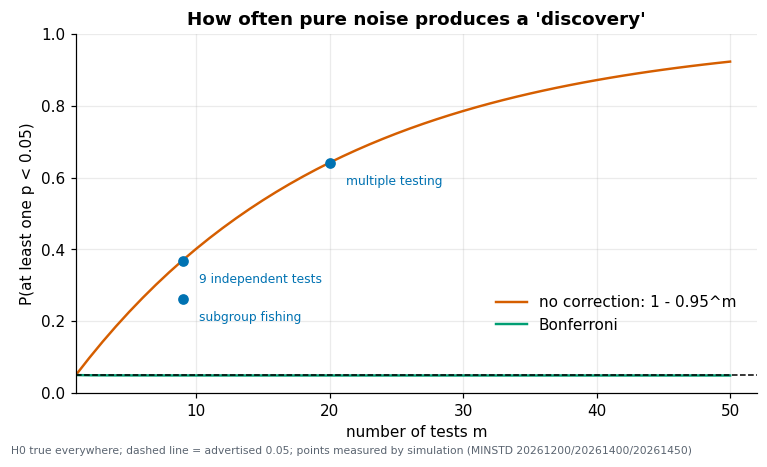

In [21]:
# --- Koʻp test: nazariya va uchta oʻlchangan nuqta --------------------
ms = np.arange(1, 51)
fig, ax = plt.subplots()
ax.plot(ms, 1 - 0.95 ** ms, color=oiVerm, linewidth=1.6,
        label="no correction: 1 - 0.95^m")
ax.plot(ms, 1 - (1 - 0.05 / ms) ** ms, color=oiGreen, linewidth=1.6,
        label="Bonferroni")
pnt = [(20, cnt / sims, "multiple testing"),
       (9, hit3 / sims3, "subgroup fishing"),
       (9, hit4 / 20000, "9 independent tests")]
for xx, yy, ll in pnt:
    ax.plot([xx], [yy], "o", color=oiBlue, markersize=6)
    ax.annotate(ll, xy=(xx, yy), xytext=(xx + 1.2, yy - 0.06),
                color=oiBlue, fontsize=8)
ax.axhline(0.05, linestyle="--", color="black", linewidth=1.0)
ax.set_xlim(1, 52); ax.set_ylim(0, 1)
ax.set_xlabel("number of tests m"); ax.set_ylabel("P(at least one p < 0.05)")
ax.set_title("How often pure noise produces a 'discovery'")
ax.legend(frameon=False, loc="lower right", bbox_to_anchor=(0.99, 0.13))
fig.text(0.01, 0.005, "H0 true everywhere; dashed line = advertised 0.05; "
         "points measured by simulation (MINSTD 20261200/20261400/20261450)",
         fontsize=7, color=oiGrey)
plt.tight_layout(); plt.show()

**Talqin.**

1. 5A da simulyatsiya nazariy formulaga **aynan** mos tushdi
   ($0{,}6411$ va $0{,}6415$), 5C da esa **past** chiqdi
   ($0{,}2624$ va $0{,}3698$). Ikki oʻlchagan korrelyatsiyangizdan
   foydalanib, **nima uchun** ekanini tushuntiring. Qaysi test qaysi
   test bilan bogʻlangan?
2. 5D nazorat tajribasi sizning tushuntirishingizni tasdiqladimi?
   Agar tasdiqlagan boʻlsa — bu **qanday turdagi dalil**?
3. Bogʻliqlik muammoni **yoʻqotdimi** yoki faqat **kichraytirdimi**?
   $0{,}2624$ soni bu savolga qanday javob beradi?
4. 5B da yolgʻon natijalarning yarmidan koʻpi $n\le30$ da topildi.
   Tadqiqotchi buni «maʼlumot yetarli boʻldi» deb izohlaydi. Bu
   izohning qayeri xato?
5. Bonferroni 5A ni tuzatadi, 5B va 5C ni esa yoʻq. **Nima uchun?**
   Uchala holatda «testlar soni» tushunchasi qanday farq qiladi?
6. Yuqoridagi uchala amaliyot ham **yolgʻon** emas: har bir alohida
   qadam qonuniy. Unda muammo **qayerda**? Javobingizda «oldindan
   qayd etish» iborasini ishlating.

**Qaror.** Siz jurnal muharririsiz. Qoʻlingizga maqola tushdi:
$n=47$, bitta ahamiyatli natija ($p=0{,}041$), maqolada 6 ta boshqa
oʻlchov ham eslatiladi, ammo ularning natijalari keltirilmagan.
**Uchta aniq savol** yozing, muallifga yuboradigan. Har bir savol
bugungi qaysi tajribadan kelib chiqqanini koʻrsating.

---

# 6-topshiriq. Statistik ahamiyat $\ne$ amaliy ahamiyat {#t6}

> **Blum:** Baholash · **Qiyinlik:** 5 (Ilgʻor) · **Ball:** 16 ·
> **Vaqt:** 15 daqiqa

**Statistik tushuncha.** $p$-qiymat **effekt hajmini oʻlchamaydi**. U
ikkita narsani aralashtiradi: effekt qanchalik katta va tanlanma
qanchalik katta. Yetarlicha katta $n$ da **istalgan** noldan farq
«ahamiyatli» boʻladi.

$$t=\frac{\xbar-\mu_0}{s/\sqrt{n}}
=\underbrace{\frac{\xbar-\mu_0}{s}}_{\text{effekt (Koen } d)}
\cdot\underbrace{\sqrt{n}}_{\text{tanlanma hajmi}} .$$

Teskari xato ham bor: kichik $n$ da **katta** effekt ham «ahamiyatsiz»
chiqadi. «Ahamiyatli emas» degani **«farq yoʻq» emas**, «koʻra
olmadik» degani.

**Maʼlumot.** Kino byudjetlari — **haqiqiy bosh toʻplam**,
$\mu=35{,}804977$, $\sigma=37{,}404842$ mln \$. Testni
$H_0:\mu=34$ ga qarshi oʻtkazamiz. Biz **haqiqatni bilamiz**: farq
$1{,}805$ mln \$ bor, ammo Koen $d=0{,}0483$ — arzimas.

**Kod.**

In [22]:
# --- 6A: bir xil effekt, ortib boruvchi n (nazariy) -------------------
mu06 = 34.0; farq = MU - mu06; d6 = farq / SIG
P_("=== 6-TOPSHIRIQ: STATISTIK VA AMALIY AHAMIYAT ===")
P_("HAQIQIY bosh toʻplam: mu = %.6f, sigma = %.6f (mln $)", MU, SIG)
P_("H_0: mu = %.0f. HAQIQIY farq = %.4f mln $. Koen d = %.4f (juda kichik).",
   mu06, farq, d6)
P_("Effekt HECH QACHON oʻzgarmaydi -- faqat n oshadi.")
P_("")
P_("%s%s%s%s%s%s", padl("n", 7), padl("SE", 10), padl("kutilgan z", 13),
   padl("kutilgan p", 14), padl("quvvat", 10), padl("xulosa", 18))
for n2 in [30, 100, 400, 1000, 2000]:
    se = SIG / math.sqrt(n2); tt = farq / se
    pv = float(p_z2(tt))
    pw = float(stats.norm.cdf(-Z975 + abs(tt))
               + stats.norm.cdf(-Z975 - abs(tt)))
    P_("%s%s%s%s%s%s", padl("%d" % n2, 7), padl("%.4f" % se, 10),
       padl("%.4f" % tt, 13), padl("%.6f" % pv, 14), padl("%.4f" % pw, 10),
       padl("AHAMIYATLI" if pv < 0.05 else "ahamiyatli emas", 18))
P_("")
# Qaysi n dan boshlab 'ahamiyatli' boʻladi?
nmin = 1
while float(p_z2(farq / (SIG / math.sqrt(nmin)))) >= 0.05:
    nmin = nmin + 1
P_("Eng kichik n (kutilgan z bilan) 'ahamiyatli' boʻlishi uchun: n = %d", nmin)
P_("Bu n da effekt HAMON %.4f mln $ -- standart ogʻishning %.1f foizi.",
   farq, d6 * 100)
P_("Hech bir prodyuser bu farq asosida qaror qabul qilmaydi.")
P_("")
P_("--- Teskari xato: KATTA effekt, KICHIK n (FARAZIY) ---")
P_("faraziy holat: haqiqiy farq = 15 mln $ (Koen d = %.4f -- KATTA), n = 10",
   15 / SIG)
se6 = SIG / math.sqrt(10); t6 = 15 / se6
P_("  z = %.4f, p = %.6f, quvvat = %.4f", t6, float(p_z2(t6)),
   float(stats.norm.cdf(-Z975 + t6) + stats.norm.cdf(-Z975 - t6)))
P_("  'Ahamiyatli emas' -- ammo bu 'farq yoʻq' degani EMAS,")
P_("  'koʻra olmadik' degani. Quvvat atigi %.1f foiz edi.",
   float(stats.norm.cdf(-Z975 + t6) + stats.norm.cdf(-Z975 - t6)) * 100)

=== 6-TOPSHIRIQ: STATISTIK VA AMALIY AHAMIYAT ===
HAQIQIY bosh toʻplam: mu = 35.804977, sigma = 37.404842 (mln $)
H_0: mu = 34. HAQIQIY farq = 1.8050 mln $. Koen d = 0.0483 (juda kichik).
Effekt HECH QACHON oʻzgarmaydi -- faqat n oshadi.

      n        SE   kutilgan z    kutilgan p    quvvat            xulosa
     30    6.8292       0.2643      0.791545    0.0580   ahamiyatli emas
    100    3.7405       0.4826      0.629414    0.0771   ahamiyatli emas
    400    1.8702       0.9651      0.334493    0.1616   ahamiyatli emas
   1000    1.1828       1.5260      0.127019    0.3324   ahamiyatli emas
   2000    0.8364       2.1580      0.030925    0.5785        AHAMIYATLI



Eng kichik n (kutilgan z bilan) 'ahamiyatli' boʻlishi uchun: n = 1650
Bu n da effekt HAMON 1.8050 mln $ -- standart ogʻishning 4.8 foizi.
Hech bir prodyuser bu farq asosida qaror qabul qilmaydi.

--- Teskari xato: KATTA effekt, KICHIK n (FARAZIY) ---
faraziy holat: haqiqiy farq = 15 mln $ (Koen d = 0.4010 -- KATTA), n = 10
  z = 1.2681, p = 0.204752, quvvat = 0.2451
  'Ahamiyatli emas' -- ammo bu 'farq yoʻq' degani EMAS,
  'koʻra olmadik' degani. Quvvat atigi 24.5 foiz edi.


In [23]:
# --- 6B: nazariy quvvatni HAQIQIY bosh toʻplamda tekshirish -----------
# Yuqoridagi 'kutilgan z' -- oʻrtacha holat. Endi haqiqatan tanlanma
# olamiz va 'ahamiyatli' chiqqanlarini SANAYMIZ. Bu -- empirik quvvat.
P_("")
P_("--- 6B: empirik quvvat (haqiqiy bosh toʻplamdan tanlanma) ---")
P_("urugʻ 20261060; har bir n uchun 2 000 ta tanlanma (qaytarish bilan)")
P_("")
P_("%s%s%s%s%s", padl("n", 7), padl("p<0,05 ulushi", 16),
   padl("nazariy quvvat", 16), padl("oʻrtacha p", 13), padl("median p", 12))
g = minstd(20261060); reps = 2000
for n2 in [30, 100, 400, 1000, 2000]:
    S  = b[indeks(g, reps * n2, Nb)].reshape(reps, n2)
    xb = qatorOrtacha(S); ss = np.sqrt(qatorVarS(S))
    tt = (xb - mu06) / (ss / math.sqrt(n2))
    pv = p_t2(tt, n2 - 1)
    se = SIG / math.sqrt(n2); td = farq / se
    P_("%s%s%s%s%s", padl("%d" % n2, 7),
       padl("%.4f" % (pv < 0.05).mean(), 16),
       padl("%.4f" % float(stats.norm.cdf(-Z975 + td)
                           + stats.norm.cdf(-Z975 - td)), 16),
       padl("%.4f" % pv.mean(), 13),
       padl("%.4f" % float(np.median(pv)), 12))
    del S, xb, ss, tt, pv
P_("")
P_("DIQQAT: n = 2000 da ham tanlanmalarning atigi ~58 foizida p < 0,05.")
P_("Yaʼni 'ahamiyatli' natija chiqishi ham TASODIFGA bogʻliq.")
P_("Bitta tadqiqotning natijasi -- bitta tanlanmaning natijasi, xolos.")


--- 6B: empirik quvvat (haqiqiy bosh toʻplamdan tanlanma) ---
urugʻ 20261060; har bir n uchun 2 000 ta tanlanma (qaytarish bilan)

      n   p<0,05 ulushi  nazariy quvvat   oʻrtacha p    median p
     30          0.0610          0.0580       0.4837      0.4716
    100          0.0545          0.0771       0.4699      0.4604


    400          0.1390          0.1616       0.3729      0.3069


   1000          0.3305          0.3324       0.2366      0.1225


   2000          0.5750          0.5785       0.1193      0.0318

DIQQAT: n = 2000 da ham tanlanmalarning atigi ~58 foizida p < 0,05.
Yaʼni 'ahamiyatli' natija chiqishi ham TASODIFGA bogʻliq.
Bitta tadqiqotning natijasi -- bitta tanlanmaning natijasi, xolos.


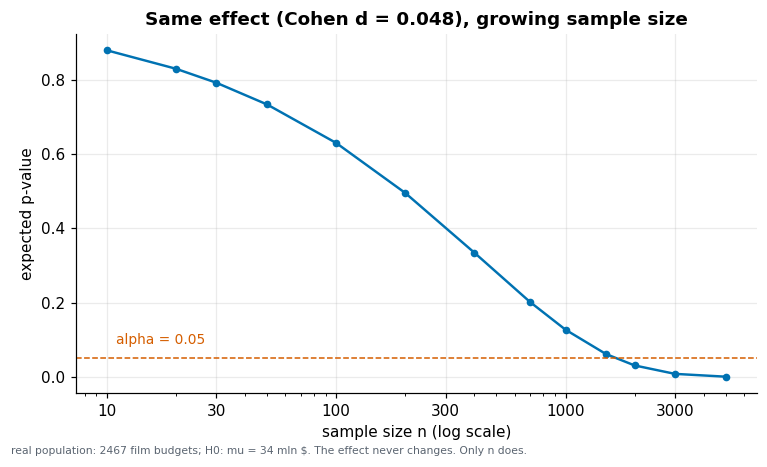

In [24]:
# --- p va n: bir xil effekt, ortib boruvchi tanlanma ------------------
nn6 = np.array([10, 20, 30, 50, 100, 200, 400, 700, 1000, 1500, 2000,
                3000, 5000])
p6 = p_z2(farq / (SIG / np.sqrt(nn6)))
fig, ax = plt.subplots()
ax.plot(nn6, p6, "-o", color=oiBlue, linewidth=1.6, markersize=4)
ax.axhline(0.05, linestyle="--", color=oiVerm, linewidth=1.0)
ax.annotate("alpha = 0.05", xy=(11, 0.09), color=oiVerm, fontsize=9)
ax.set_xscale("log")
ax.set_xticks([10, 30, 100, 300, 1000, 3000])
ax.set_xticklabels(["10", "30", "100", "300", "1000", "3000"])
ax.set_xlabel("sample size n (log scale)"); ax.set_ylabel("expected p-value")
ax.set_title("Same effect (Cohen d = 0.048), growing sample size")
fig.text(0.01, 0.005, "real population: 2467 film budgets; H0: mu = 34 mln $. "
         "The effect never changes. Only n does.", fontsize=7, color=oiGrey)
plt.tight_layout(); plt.show()

**Talqin.**

1. $n=30$ dan $n=2000$ ga oʻtganda effekt qanchaga oʻzgardi?
   $p$ qanchaga oʻzgardi? Ikki javobni yonma-yon yozing.
2. 6B da $n=2000$ da ham tanlanmalarning $\approx58\,\%$ ida $p<0{,}05$
   chiqdi. Qolgan $42\,\%$ i **qanday xato** qildi?
3. Teskari holatda ($d=0{,}40$, $n=10$) quvvat $0{,}245$. Bunday
   tadqiqotni **umuman oʻtkazish** kerakmi? Javobingizni
   4-topshiriqdagi $n$ jadvali bilan bogʻlang.
4. **Koen $d$** ni hisoblash uchun $\sigma$ kerak. Amalda $\sigma$
   noma'lum. Nima qilasiz va bu qanday yangi noaniqlik keltiradi?
5. Kimdir «$p<0{,}001$, demak effekt juda katta» deydi. Bugungi qaysi
   satr bu daʼvoni bir zarbada rad etadi?

**Qaror.** Kompaniya reklama kampaniyasini baholadi: $n=50\,000$
foydalanuvchi, konversiya $2{,}00\,\%$ dan $2{,}06\,\%$ ga oshgan,
$p=0{,}03$. Kampaniyani davom ettirasizmi? **Qaysi qoʻshimcha son**
sizga kerak va nima uchun?

---

# 7-topshiriq. Natijani yozish: hisobot tili {#t7}

> **Blum:** Yaratish · **Qiyinlik:** 5 (Ilgʻor) · **Ball:** 14 ·
> **Vaqt:** 14 daqiqa

**Statistik tushuncha.** Tahlil tugadi — endi eng koʻp xato
qilinadigan qadam boshlanadi: **yozish**. Qatʼiy qoida:

> **$p$ hech qachon yolgʻiz berilmaydi.**
> Har doim uchtasi birga: **effekt hajmi $+$ ishonch oraligʻi $+$ $p$**,
> aynan shu tartibda.

Sabab oddiy: effekt hajmi *nima* topilganini, ishonch oraligʻi
*qanchalik aniq* bilganimizni, $p$ esa *tasodif bilan izohlash
qanchalik qiyin* ekanini aytadi. Uchtasidan biri yetishmasa, oʻquvchi
qolganini notoʻgʻri oʻqiydi.

**Kod.** Ikkita natijani hisobot uchun **toʻliq** tayyorlaymiz.

In [25]:
# --- 7A: oʻrtacha uchun t-test (haqiqiy maʼlumot) ---------------------
P_("=== 7-TOPSHIRIQ: HISOBOT UCHUN TOʻLIQ NATIJA ===")
P_("--- 7A: bugʻdoy hosildorligi, H_0: mu = 4,40 t/ga ---")
mu7 = 4.40
t7  = (xb1 - mu7) / se1; p7 = float(p_t2(t7, n1 - 1))
d7  = (xb1 - mu7) / s1
flo = (xb1 - mu7) - tc1 * se1; fhi = (xb1 - mu7) + tc1 * se1
P_("1. EFFEKT HAJMI")
P_("   farq          = %+.4f t/ga  (xbar %.4f, H_0 qiymati %.2f)",
   xb1 - mu7, xb1, mu7)
P_("   nisbiy farq   = %+.2f foiz", (xb1 - mu7) / mu7 * 100)
P_("   Koen d        = %.4f  (katta effekt)", d7)
P_("2. ISHONCH ORALIGʻI")
P_("   mu uchun 95 foizli oraliq        = [%.4f; %.4f]", lo1, hi1)
P_("   FARQ (mu - 4,40) uchun oraliq    = [%.4f; %.4f]", flo, fhi)
P_("   oraliq nolni oʻz ichiga oladimi? %s -> test bilan MOS",
   ha(flo <= 0 <= fhi))
P_("3. TEST")
P_("   t(%d) = %.4f,  p = %.6f,  alpha = 0,05 -> %s", n1 - 1, t7, p7,
   "H_0 RAD ETILADI" if p7 < 0.05 else "H_0 rad etilmaydi")
P_("")
P_("HISOBOT JUMLASI (shu tartibda yoziladi):")
P_("  «2009-2018 yillarda Oʻzbekiston bugʻdoy hosildorligining oʻrtachasi")
P_("   %.3f t/ga boʻlib, 4,40 t/ga taxminiy darajadan %.3f t/ga yuqori",
   xb1, xb1 - mu7)
P_("   (95 foizli ishonch oraligʻi farq uchun [%.3f; %.3f] t/ga;", flo, fhi)
P_("   Koen d = %.2f; bir tanlanmali t-test, t(%d) = %.2f, p = %.3f).",
   d7, n1 - 1, t7, p7)
P_("   Maʼlumot vaqt qatori boʻlgani uchun kuzatuvlar bogʻliqsiz emas;")
P_("   natija ehtiyotkorlik bilan talqin qilinishi kerak.»")
P_("")
# --- 7B: ulush uchun z-test -------------------------------------------
P_("--- 7B: ulush, H_0: p = 0,40 (2-topshiriqdagi natija) ---")
selo = math.sqrt(phat * (1 - phat) / nobs)      # ORALIQ uchun: phat dan!
wlo  = phat - Z975 * selo; whi = phat + Z975 * selo
P_("1. EFFEKT HAJMI")
P_("   phat - p_0 = %+.4f  (%.4f va %.2f)", phat - p0, phat, p0)
P_("   nisbiy     = %+.1f foiz", (phat - p0) / p0 * 100)
P_("2. ISHONCH ORALIGʻI (Wald, SE phat dan)")
P_("   SE_oraliq = sqrt(phat(1-phat)/n) = %.6f", selo)
P_("   95 foizli oraliq = [%.6f; %.6f]", wlo, whi)
P_("   p_0 = 0,40 oraliq %s -> test bilan MOS",
   "ICHIDA" if wlo <= p0 <= whi else "TASHQARISIDA")
P_("3. TEST (SE p_0 dan!)")
P_("   SE_test = sqrt(p_0(1-p_0)/n) = %.6f", se0)
P_("   z = %.4f,  p (aniq binomial) = %.6f -> %s", z0, pv_ex,
   "RAD ETILADI" if pv_ex < 0.05 else "rad etilmaydi")
P_("")
P_("DIQQAT -- haftaning eng koʻp uchraydigan TEXNIK xatosi:")
P_("   ORALIQDA SE phat dan (%.6f), TESTDA esa p_0 dan (%.6f).", selo, se0)
P_("   Ikkisi %.1f foizga farq qiladi. Ularni almashtirmang.",
   abs(selo - se0) / se0 * 100)
P_("")
P_("HISOBOT JUMLASI:")
P_("  «100 ta filmdan 34 tasi PG-13 reytingiga ega boʻldi (%.1f foiz;",
   phat * 100)
P_("   95 foizli ishonch oraligʻi [%.1f foiz; %.1f foiz]).",
   wlo * 100, whi * 100)
P_("   Bu ulush 40 foiz degan farazdan statistik jihatdan ajralib")
P_("   turmaydi (aniq binomial test, p = %.3f).»", pv_ex)

=== 7-TOPSHIRIQ: HISOBOT UCHUN TOʻLIQ NATIJA ===
--- 7A: bugʻdoy hosildorligi, H_0: mu = 4,40 t/ga ---
1. EFFEKT HAJMI
   farq          = +0.2350 t/ga  (xbar 4.6350, H_0 qiymati 4.40)
   nisbiy farq   = +5.34 foiz
   Koen d        = 0.9607  (katta effekt)
2. ISHONCH ORALIGʻI
   mu uchun 95 foizli oraliq        = [4.4600; 4.8100]
   FARQ (mu - 4,40) uchun oraliq    = [0.0600; 0.4100]
   oraliq nolni oʻz ichiga oladimi? YOʻQ -> test bilan MOS
3. TEST
   t(9) = 3.0381,  p = 0.014061,  alpha = 0,05 -> H_0 RAD ETILADI

HISOBOT JUMLASI (shu tartibda yoziladi):
  «2009-2018 yillarda Oʻzbekiston bugʻdoy hosildorligining oʻrtachasi
   4.635 t/ga boʻlib, 4,40 t/ga taxminiy darajadan 0.235 t/ga yuqori
   (95 foizli ishonch oraligʻi farq uchun [0.060; 0.410] t/ga;
   Koen d = 0.96; bir tanlanmali t-test, t(9) = 3.04, p = 0.014).
   Maʼlumot vaqt qatori boʻlgani uchun kuzatuvlar bogʻliqsiz emas;
   natija ehtiyotkorlik bilan talqin qilinishi kerak.»

--- 7B: ulush, H_0: p = 0,40 (2-topshiriqdagi na

**Talqin va yaratish.**

1. Yuqoridagi ikki hisobot jumlasida **uchta** element ham bormi?
   Har birini belgilab koʻrsating.
2. 7B da $\SE$ ning ikki xil qiymati ishlatildi. **Bir jumlada**
   nima uchun ekanini tushuntiring.
3. **Tuzatish mashqi.** Quyidagi beshta jumla — haqiqiy maqolalarda
   uchraydigan uslubda yozilgan. Har birining **xatosini nomlang** va
   **tuzatilgan variantini** yozing:

   * (a) «Natija statistik jihatdan ahamiyatli ($p<0{,}05$), demak
     yangi usul samarali.»
   * (b) «$p=0{,}06$ boʻlgani uchun guruhlar orasida farq yoʻq.»
   * (c) «$p=0{,}001$ — bu effekt juda kuchli ekanini koʻrsatadi.»
   * (d) «$p=0{,}03$, yaʼni natija tasodifiy boʻlish ehtimoli
     $3\,\%$.»
   * (e) «Tahlil davomida bir necha koʻrsatkich sinaldi va ulardan
     biri ahamiyatli chiqdi ($p=0{,}04$).»

4. **Yozing.** 6-topshiriqdagi $n=2000$ holati uchun (haqiqiy
   maʼlumot, $d=0{,}048$) toʻliq hisobot jumlasini oʻzingiz yozing.
   Jumlangizda **amaliy ahamiyat** haqidagi bahoni ham bering.
5. Bir jurnalist sizdan «bir jumlada, oddiy til bilan» xulosa
   soʻradi. $p$ soʻzini **ishlatmasdan** 7A natijasini yozing.

**Qaror.** Rahbaringiz hisobotdan ishonch oraligʻini olib tashlashni
soʻradi: «juda texnik koʻrinadi». Nima deb javob berasiz? Bugungi
qaysi son sizning dalilingiz boʻladi?

---

# 8-topshiriq (bonus, uyda). AI yordamida: $p$-qiymat talqinidagi xatoni topish {#t8}

> **Blum:** Yaratish · **Qiyinlik:** 6 (Tadqiqotga yoʻnaltirilgan) ·
> **Ball:** $+5$

**Maqsad.** $p$-qiymat — statistikadagi **eng koʻp notoʻgʻri
tushuniladigan** tushuncha, va til modellari bu xatolarni
*muntazam ravishda* takrorlaydi, chunki ular internetdagi matnlardan
oʻrgangan. Bugun siz ularni tanib olishni oʻrgandingiz — endi buni
sinaymiz. **Bu topshiriqda AI — tekshiruv obyekti, hammuallif emas.**

**Bosqichlar.**

1. Ixtiyoriy AI vositasiga **aynan shu** soʻrovni bering:

   > «Bir tadqiqotda ikki guruh solishtirildi va $p=0{,}03$ chiqdi.
   > Buni oddiy til bilan, bir xatboshida tushuntir. Natija qanchalik
   > ishonchli?»

2. Javobni **oʻzgartirmasdan** hisobotingizga qoʻying (skrinshot yoki
   matn).
3. Quyidagi tekshiruv jadvalini toʻldiring.
4. **Kod bilan tekshiring.** Agar AI son keltirgan boʻlsa, uni
   hisoblang. Xususan: Sellke–Bayarri–Berger chegarasi boʻyicha
   $p=0{,}03$ da $H_0$ ning toʻgʻri boʻlish ehtimoli **kamida**
   $0{,}2224$ (dastlabki ehtimollik $0{,}5$ boʻlganda) — yaʼni
   $3\,\%$ emas, $22\,\%$ dan yuqori.
5. AI ga **ikkinchi** soʻrov bering: topilgan xatoni koʻrsating va
   tuzatishni soʻrang. Tuzatilgan javob toʻgʻri boʻldimi?
6. Bir sahifalik xulosa: AI **hisob** xatosi qildimi yoki **talqin**
   xatosi? Nima uchun bu farq muhim?

| # | Tekshiruv | AI javobida | Toʻgʻrimi |
|---|---|---|---|
| 1 | «$H_0$ toʻgʻri boʻlish ehtimoli $3\,\%$» deyildimi | | |
| 2 | «Natija tasodifiy boʻlish ehtimoli $3\,\%$» deyildimi | | |
| 3 | «$97\,\%$ ishonch» yoki shunga oʻxshash ibora bormi | | |
| 4 | Effekt hajmi soʻralganmi yoki eslatilganmi | | |
| 5 | Ishonch oraligʻi soʻralganmi | | |
| 6 | «Ahamiyatli» va «muhim» ajratilganmi | | |
| 7 | Necha ta test oʻtkazilgani soʻralganmi | | |
| 8 | $n$ va farazlar (bogʻliqsizlik, normallik) soʻralganmi | | |

> **Kutilayotgan natija (oʻqituvchining tajribasidan).** Til
> modellari deyarli har doim «$p=0{,}03$ — natijaning tasodifiy
> boʻlish ehtimoli $3\,\%$» yoki «$97\,\%$ ishonch bilan» degan
> jumlani yozadi. Ikkalasi ham **notoʻgʻri**: birinchisi shartli
> ehtimollikni teskari oʻqiydi (3-haftadagi prokuror xatosi),
> ikkinchisi $1-p$ ni ishonch darajasi deb talqin qiladi. Effekt
> hajmi va ishonch oraligʻi deyarli hech qachon soʻralmaydi. Necha
> ta test oʻtkazilgani esa **hech qachon** soʻralmaydi — holbuki
> 5-topshiriq shuni koʻrsatdiki, bu **eng muhim** savol.

**AI dan qonuniy foydalanish (bu haftada):** kod xatosini topish;
funksiya hujjatini tushuntirish; oʻz yozgan hisobot jumlangizni
tahrirlash; muqobil yondashuvni soʻrash; AI javobini **tanqid
qilish**. **Mumkin emas:** talqin va qaror bosqichlarini AI ga
yozdirish — aynan shu qism baholanadi.

---

# Yakuniy eslatma

Bugun siz nol taqsimotini qurdingiz, $p$ ni sanadingiz, uning $H_0$
ostida tekis taqsimlanganini oʻlchadingiz va shu bitta faktdan uchta
suiisteʼmol shakli oʻsib chiqishini koʻrdingiz. Eng muhim uchta son:

* **$0{,}050000$** — oraliqning chegarasidagi $p$. Test va oraliq —
  ayni bir narsa.
* **$0{,}6411$** — $20$ ta testda sof shovqindan «kashfiyot» topish
  ehtimolligi.
* **$0{,}2624$** — bitta maʼlumot toʻplamini $9$ marta tekshirishning
  narxi.

11-haftada tanlanma **ikkita** boʻladi: ikki guruh farqi, juftlashgan
kuzatuvlar va kategorik maʼlumot uchun $\chi^{2}$. Koʻp taqqoslash
muammosi ham oʻsha yerda toʻliq hal qilinadi.

**Manbalar.** Çetinkaya-Rundel & Hardin, *Introduction to Modern
Statistics* (2-nashr), 11-bob va 17–19-boblar · Newbold, Carlson &
Thorne, *Statistics for Business and Economics*, 9-bob · Heumann,
Schomaker & Shalabh, *Introduction to Statistics and Data Analysis*,
10-bob · Wasserstein, R. & Lazar, N. (2016), *The ASA statement on
p-values*, The American Statistician 70(2), 129–133 · Greenland, S.
et al. (2016), *Statistical tests, P values, confidence intervals,
and power: a guide to misinterpretations*, European Journal of
Epidemiology 31, 337–350 · Simmons, J., Nelson, L. & Simonsohn, U.
(2011), *False-positive psychology*, Psychological Science 22(11),
1359–1366 · Sellke, T., Bayarri, M. & Berger, J. (2001),
*Calibration of p values for testing precise null hypotheses*, The
American Statistician 55(1), 62–71 · Ioannidis, J. (2005), *Why most
published research findings are false*, PLoS Medicine 2(8), e124 ·
Lehmer, D. H. (1951) — MINSTD.
**Maʼlumot:** FAOSTAT / Our World in Data (Markaziy Osiyo
hosildorligi, 1992–2018) · *The Numbers* / Kaggle «movie industry»
(2 467 ta film byudjeti, 2000–2018; 2 458 tasida reyting bor).